# NASDAQ-100 Microstructure — Strategy Analysis

This notebook turns the backtest registry for the NASDAQ-100 microstructure
case study into one strategy assessment. It reports every metric with an
interval rather than as a point, compares strategies against each other in
pairs rather than by subtracting summary numbers, and reads the holdout once.
Comparison against other case studies is reserved for the synthesis chapter.

Two ideas run through it. **Paired comparison**: two strategies evaluated on
the same days are compared day by day, so the shared market movement cancels
and what is left is the difference between them. Subtracting one summary
statistic from another throws that pairing away and produces an interval far
wider than the evidence warrants. **Block bootstrap**: intervals are built by
resampling contiguous blocks of days rather than individual days, because
returns on consecutive days are related and resampling them independently would
understate the uncertainty.

**Learning objectives**

- Read backtest metrics with their intervals from the registry rather than
  transcribing point estimates
- Trace one selected lineage through the pipeline stages and attribute the
  change at each stage to the field that stage varied
- Compare a strategy against an equal-weight benchmark on the same days, on
  both the validation and the holdout window
- State a gate so that it can fail, and say what passing it does and does not
  establish

**Book reference**: Chapter 20, §20.1 (the §9 handoff feeds Ch20's
cross-case-study aggregation).

**Prerequisites**: case-study pipeline through `14_backtest`; the
locked registry (`case_studies/nasdaq100_microstructure/run_log/registry.db`).

**Scope**: no training and no re-backtesting. The notebook reads what
`14_backtest` through `17_costs` registered, and derives
`cohort_metrics` and `backtest_paired_metrics` from those runs itself when
they are absent, so the case study no longer depends on a chapter-20
notebook having been run first. On an already-populated registry it writes
nothing.

In [1]:
"""NASDAQ-100 Microstructure — Strategy Analysis."""

import json
import sqlite3

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl

# ml4t.diagnostic loads cudart; torch must import first, so its bundled runtime wins symbol
# resolution. Imported for that side effect alone, which ruff cannot see - without the noqa
# a dead-import sweep deletes it and the notebook fails on the cudart load.
import torch  # noqa: F401
import yaml
from ml4t.diagnostic.evaluation import PortfolioAnalysis
from ml4t.diagnostic.integration import (
    BacktestReportMetadata,
    generate_tearsheet_from_run_artifacts,
)

from case_studies.research import read_only_study
from case_studies.utils.backtest_explorer import BacktestExplorer
from case_studies.utils.benchmark import load_benchmark_metrics, load_benchmark_returns
from case_studies.utils.cohort_metrics import compute_and_register
from case_studies.utils.factor_attribution import (
    compute_bootstrap_ci,
    compute_rolling_exposures,
    format_attribution_summary,
    load_factor_data,
    plot_attribution_waterfall,
    plot_rolling_exposures,
    run_factor_regression,
)
from case_studies.utils.notebook_contracts import (
    degenerate_prediction_sql,
    derived_tables_off_canonical_universe,
    strategy_input_counts,
)
from case_studies.utils.paired_metrics import populate_paired_metrics, rung_for
from case_studies.utils.registry import (
    load_backtest_fold_metrics,
    load_backtest_metrics,
    load_paired_metrics,
)
from case_studies.utils.strategy_analysis import (
    ci_status,
    compute_operating_profile,
    fmt_gate,
    gate1_validation_sharpe_geq_zero,
    gate2_holdout_diff_not_excludes_zero_negatively,
    gate_passes,
    plot_concentration_curve,
    plot_equity_drawdown,
    plot_sharpe_waterfall,
    resolve_solvent_carrier,
    write_strategy_assessment,
)
from case_studies.utils.sweep_config import get_universe_filters_for
from case_studies.utils.uncertainty import ENTIRE_REGISTRY, NO_CARRIER
from utils.paths import get_output_dir
from utils.style import show_with_alt

# Figures go through `show_with_alt`, and none of them calls `tight_layout()`. Both are
# measured rather than stylistic: `utils/style` and `matplotlibrc` set
# `figure.constrained_layout.use`, so `tight_layout()` warns and fights the layout engine
# already running, and `fig.show()` on a non-interactive backend warns that the canvas
# cannot be shown - two UserWarnings per figure, written into the rendered cell. The six
# notebooks of this case study already at `done` use this form and neither of the others.
#
# The alt strings name structure, axes and reference lines, never which series wins. An
# ordering is a registry result a rebuild can reverse, and alt text is prose no rebuild
# revisits, so a ranking written here would go stale silently on the one surface a reader
# who cannot see the chart depends on.

In [2]:
CASE_STUDY = "nasdaq100_microstructure"
MAX_SYMBOLS = 0
# Where this notebook reads. Empty means the canonical registry; a smoke run passes the
# workspace the stages before it wrote to.
EXECUTION_TIER = "canonical"
WORKSPACE: str = ""

This notebook reads; it registers nothing, and that decides how it opens the registry. Every
route through `open_study` ends in `Study.activate()`, which rewrites `ML4T_OUTPUT_DIR` for
the rest of the process and clears the caches keyed on it, so every later
`get_case_study_dir` answers for a different directory than the one resolved here. On the
canonical tier with no workspace that route is `Study.regenerate`, which refuses outright
unless `features`, `labels` and `run_log` are symlinks - true in a maintainer worktree, false
in every clean clone.

`read_only_study` is the form that does not activate: it resolves the root for the tier and
workspace it is given and hands back a `Study.at` over it, which points the path helpers at
that root rather than clearing the variable. `CASE_DIR` is that root, and every question this
notebook asks - the catalog, the lineage, the populations, the artifacts - is answered from
it.

In [3]:
study = read_only_study(
    CASE_STUDY,
    workspace=WORKSPACE or None,
    execution_tier=EXECUTION_TIER,
    entry_point="20_strategy_analysis",
)
CASE_DIR = study.root
PERIODS_PER_YEAR = 252  # strategy returns are aggregated to daily before Sharpe
OUTPUT_DIR = get_output_dir(20, CASE_STUDY)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

with open(CASE_DIR / "config" / "setup.yaml") as f:
    setup = yaml.safe_load(f)

explorer = BacktestExplorer(CASE_STUDY)
print(explorer)

BacktestExplorer('nasdaq100_microstructure', 3908 runs: allocation=60, cost_sensitivity=35, holdout=1, risk_overlay=20, signal=3792)


### Produce the derived tables this notebook reads

`cohort_metrics` and `backtest_paired_metrics` are read below - the first for the deflated
Sharpe and PBO columns, the second to find the validation counterpart of a holdout run. Until
now nothing in this case study wrote either. The header of this notebook said so outright:
they "were populated by `20_strategy_synthesis/01_aggregate_synthesis.py`", a chapter-20
notebook. A case study that depends upward into the chapter that aggregates it cannot be run
from its own pipeline, and its numbers exist only after something outside it happens to run.

Both producers already exist as case-study-scoped functions, extracted from those very Ch20
loops - `populate_paired_metrics` says so in its own docstring - and `cme_futures/17` is the
notebook that uses them. This adopts the same pattern.

Population is idempotent (keyed upserts, reproducing stored values exactly), but it still
rewrites the registry, so it runs only when a table is absent or empty. On an already-populated
registry this notebook stays a pure reader and touches nothing.

In [4]:
_db = CASE_DIR / "run_log" / "registry.db"
_counts_before = strategy_input_counts(CASE_DIR)
_n_backtests = _counts_before["backtest_runs"]
_n_cohorts = _counts_before["cohort_metrics"]
_n_pairs = _counts_before["backtest_paired_metrics"]

if _n_backtests == 0:
    # Refuse rather than report. Every figure and gate below is computed from backtest runs, so
    # with none registered this notebook does not produce a weaker answer - it produces an empty
    # one that reads like a finished analysis. `14_backtest` is what fills this.
    raise RuntimeError(
        f"{CASE_STUDY} has no registered backtest runs, so there is nothing to analyse. "
        "Run 14_backtest through 17_costs first; this notebook reads what they "
        "register and computes no backtests of its own."
    )

# Both producers need this case study's canonical selection, and passing neither is not a
# smaller version of passing both - it is a different selection. `setup.yaml` says the
# full-universe variant "is NOT a canonical rank-1 / cohort / DSR candidate" and lives only in
# the 17_costs comparison, so a cohort computed without the filter mixes rows the case study
# excludes by declaration into the leaders, trial counts, DSR and PBO. The filter is read from
# `setup.yaml` rather than written here, so it cannot disagree with the sweep that produced the
# runs. The rung pin is the matching statement for paired metrics: nasdaq's carrier is the
# cost-feasible ensemble, fixed before the holdout was opened.
_UNIVERSE_FILTER = get_universe_filters_for(CASE_STUDY)[0]
_RUNG = rung_for(CASE_STUDY)

# The two tables are filled independently. A single `if either is empty` guard recomputed both,
# and `compute_and_register` writes with `replace_all=True` - so a registry with correct cohorts
# and an empty paired table would have had its cohorts replaced as a side effect of populating
# the pairs.
# A row count answers "has this been populated", which is not what a rerun needs to know. Both
# tables are written from a selection, and one populated by an earlier run that selected
# differently - before this notebook passed the universe filter, say - is fully populated and
# wrong. Neither table records the selection that produced it, so it is recovered from what the
# rows point at: a canonical row cannot reference a backtest run outside the canonical universe.
_stale = derived_tables_off_canonical_universe(CASE_DIR, _UNIVERSE_FILTER)
for _table in sorted(_stale):
    print(f"{_table} references runs outside {_UNIVERSE_FILTER}, so it is rebuilt")

if _n_cohorts == 0 or "cohort_metrics" in _stale:
    # `compute_and_register` writes with `replace_all=True`, so a rebuild that computes no
    # cohort empties the table rather than leaving the previous one - the opposite of what
    # `populate_paired_metrics` does on the same failure. An emptied table is also clean by
    # the universe check below, which reads rows and finds none, so the wipe would pass
    # unnoticed and every cohort figure would render blank. Catch it here, where the before
    # and after counts are both in hand.
    _n_cohorts_before = _n_cohorts
    # Cohorts are scoped by the rung's universe filter and by nothing else: every
    # prediction set on that rung counts toward K, retired generations included.
    _counts = compute_and_register(
        CASE_STUDY, universe_filter=_UNIVERSE_FILTER, prediction_hashes=ENTIRE_REGISTRY
    )
    _n_cohorts = sum(_counts[k] for k in ("family", "stagelabel", "label"))
    if _n_cohorts == 0:
        # Backtests are registered - the refusal above guarantees it - so a run that computes
        # no cohort means the canonical selection matched nothing, or matched too few variants
        # per group for a cohort to exist. Either way the selection-bias figures have no input,
        # and rendering them blank reads like an analysis that found nothing rather than one
        # that was never computed. That is the same reason this notebook refuses an empty
        # `backtest_runs`, so it refuses here too.
        _lost = (
            f" and replaced {_n_cohorts_before} existing rows with none"
            if _n_cohorts_before > 0
            else ""
        )
        raise RuntimeError(
            f"rebuilding cohort_metrics for {_UNIVERSE_FILTER} produced no cohort{_lost}. "
            f"Check that {_UNIVERSE_FILTER} matches the backtest runs this case study "
            f"registered, and that the sweep left more than one variant per cohort."
        )
    print(f"populated cohort_metrics: {_n_cohorts} rows")
else:
    print(f"already populated: cohort_metrics {_n_cohorts} rows")

# Rebuilt every run, where cohorts above are rebuilt only when they look wrong. The universe
# recovery cannot answer this table's question. It reads what the rows point at, and a pair
# written under an earlier pin points at a backtest that is still inside the current one: when
# `family == "ensemble"` left this case study's pin on 2026-09-14 the rank-1 rung moved from the
# ensemble at +0.566 to `deep_learning/nlinear` at +2.300, and the ensemble row it had already
# written stayed canonical, stayed cost-feasible and stayed `fwd_ret_15m`. Nothing about it
# reads as stale, because being outside the pin and no longer being what the pin selects are
# different things, and only the first is recoverable from the row. A row count answers neither.
# So it is recomputed rather than validated. `replace_all=True` makes the call a complete
# snapshot, and it costs about a second against this notebook's 25 to 40.
# `NO_CARRIER` is the raw-Sharpe ranking inside the producer rather than a resolved
# lineage: this case study pins a rung the canonical resolver does not know about.
_pairs = populate_paired_metrics(
    CASE_STUDY,
    explorer,
    rung=_RUNG,
    replace_all=True,
    carrier=NO_CARRIER,
    prediction_hashes=ENTIRE_REGISTRY,
)
_n_pairs = sum(1 for row in _pairs if "skip" not in row)
print(f"populated backtest_paired_metrics: {_n_pairs} pairs")

# A rebuild that could not produce a canonical table leaves the previous one in place, which
# is the right call for the data - a stale table is recoverable and deleted rows are not - but
# the wrong one for this notebook, which would go on to read those rows and present selection
# statistics computed under a universe the chapter does not claim. Refuse instead of rendering
# them. An unpopulated registry has nothing off-universe to find and never reaches this.
_still_stale = derived_tables_off_canonical_universe(CASE_DIR, _UNIVERSE_FILTER)
if _still_stale:
    raise RuntimeError(
        f"{', '.join(sorted(_still_stale))} still reference runs outside "
        f"{_UNIVERSE_FILTER} after rebuilding. The rebuild produced nothing to replace them "
        f"with, so every figure below would describe a selection this case study does not "
        f"make. Re-run the backtests for {_UNIVERSE_FILTER} before this notebook."
    )


def _fmt_ci(point: float | None, lo: float | None, hi: float | None, fmt: str = ".3f") -> str:
    if point is None:
        return "—"
    p = format(point, fmt)
    if lo is None or hi is None:
        return f"{p} [—, —]"
    return f"{p} [{format(lo, fmt)}, {format(hi, fmt)}]"


def _fmt(val: float | None, fmt: str = ".4f") -> str:
    return "—" if val is None else format(val, fmt)

already populated: cohort_metrics 23 rows


  skip signal -> allocation: the allocation leader is not built on the signal leader
  skip allocation -> cost_sensitivity: the cost_sensitivity leader is not built on the allocation leader
[paired_metrics] nasdaq100_microstructure: 1 pairs written, 1 skipped


    + equal_weight_side_artifact: sharpe_diff=0.49523749639514514


    - equal_weight_holdout_side_artifact: no_holdout_challenger_returns


populated backtest_paired_metrics: 1 pairs


## §1 Handoff from model analysis

The strategy phase inherits one configuration, chosen once on validation results
only, across the stages that are eligible for the holdout - signal, allocation
and risk overlay.

The selection is made by `resolve_solvent_carrier`, the shared resolver, and not by
ranking a Sharpe column here. The same resolver answers `18_holdout_predictions` and
`19_holdout_backtest`, so this page reports the configuration those notebooks refitted
and priced. It refuses rather than selecting past a problem, on three conditions that
are all permanent: a rank-1 with no recorded `max_drawdown`, one whose drawdown reached
-100% so its Sharpe is arithmetic on an account that no longer exists, and one fitted
under a conformal calibration version `run_backtest` will no longer execute.

**On this case study the eligible stages come to one.** `UNIVERSE_RESTRICTIONS` pins
rank-1 to the `cost_feasible` universe that `backtest.sweep.universe_filter` declares
canonical, and `15_portfolio_management` and `16_risk_management` both register
specs carrying no `universe_filter`. So the allocation and risk-overlay stages
contribute no eligible rows here and the carrier is a baseline-stage configuration.

The label is taken from the selection rather than assumed. The pool spans every
declared label, so the chosen strategy may rest on a variant label rather than the
primary one, and every loader downstream follows the selection rather than the default.

**Here it does.** `config/setup.yaml` declares `fwd_ret_15m` primary, and the
selection lands on `fwd_dir_15m`, the direction variant, because that is where the
best validation Sharpe is. The consequence is worth stating rather than leaving a
reader to infer it from two labels appearing in different tables: the holdout was
spent on the variant. The primary label is where the stage sweeps ran, carrying all
60 allocation and all 20 risk-overlay backtests against the variant's none, while
the variant carries the single holdout row. So the allocation and overlay evidence
in the sections below describes one label and the out-of-sample evidence in §6
describes another. Each is read on the configuration that produced it and neither
stands in for the other.

In [5]:
carrier = resolve_solvent_carrier(CASE_STUDY)
TOP_HASH = carrier["val_backtest_hash"]
TOP_PHASH = carrier["val_prediction_hash"]
RANK1_FAMILY = carrier["family"]
RANK1_CONFIG = carrier["config_name"]
RANK1_LABEL = carrier["label"]
PRIMARY_LABEL = RANK1_LABEL

_db = CASE_DIR / "run_log" / "registry.db"
with sqlite3.connect(str(_db)) as _con:
    _row = _con.execute(
        "SELECT ic_mean_daily, ic_ci_lo, ic_ci_hi, ic_t_hac, ic_p_hac, ic_n_days, "
        "ic_hac_lag, ic_pct_positive "
        "FROM prediction_metrics WHERE prediction_hash = ?",
        (TOP_PHASH,),
    ).fetchone()

ic_mean, ic_lo, ic_hi, ic_t, ic_p, ic_ndays, ic_lag, ic_pct = _row

print(f"Rank-1: family={RANK1_FAMILY}, config={RANK1_CONFIG}, label={PRIMARY_LABEL}")
print(f"        prediction_hash={TOP_PHASH}, backtest_hash={TOP_HASH}")
print()
print("Daily-pooled IC (validation):")
print(f"  IC = {_fmt_ci(ic_mean, ic_lo, ic_hi, '.4f')}  (HAC, lag={int(ic_lag)})")
print(f"  t_HAC = {ic_t:.3f}, p_HAC = {ic_p:.3f}")
print(f"  n_days = {int(ic_ndays)}, pct_positive = {ic_pct:.1%}")
print(f"  CI status: {ci_status(ic_lo, ic_hi)}")

Rank-1: family=gbm, config=default_multiclass, label=fwd_dir_15m
        prediction_hash=4893bf8b35dc, backtest_hash=a2d22880e93f

Daily-pooled IC (validation):
  IC = 0.0076 [0.0052, 0.0100]  (HAC, lag=17)
  t_HAC = 6.258, p_HAC = 0.000
  n_days = 78812, pct_positive = 52.3%
  CI status: excludes_zero_strong


The cells above report the selected prediction set's own score and interval
from `prediction_metrics`. Read the interval rather than the point: it says
whether the ordering the strategy trades on is distinguishable from no
ordering at all, which is the precondition for anything downstream.

The probabilistic Sharpe ratio reported later asks a related question about
the strategy rather than the signal - whether its Sharpe is distinguishable
from zero once the shape of its return distribution is accounted for. A
strategy with occasional large gains and many small losses can show a
flattering Sharpe that this correction discounts.

This case study declares no strategy-specific stopping conditions in
`setup.yaml`, so §9 evaluates two conditions that apply to any strategy:
whether the validation interval's lower bound reaches zero, and whether the
holdout comparison against the benchmark excludes zero on the negative side.
Each is reported as pass, partial or fail.

## §2 Search context, family comparison, and lineage waterfall

The baseline stage produced many validation backtests across the model families
and label horizons. The selected row is one outcome of that search, and a
search over many configurations produces a highest value even when none of the
configurations has an edge.

Two things put it in context. Where it sits within its own family's
distribution says whether it stands apart from its neighbours or is the top of
a tightly packed band. How it changes through the pipeline stages says which
stage moved it, and by how much relative to the uncertainty in that move.

In [6]:
ctx = explorer.search_context("signal")
search_table = pl.DataFrame(
    [
        {"metric": "Total signal backtests", "value": f"{ctx['total']:,}"},
        {"metric": "Mean Sharpe", "value": f"{ctx['mean_sharpe']:.3f}"},
        {"metric": "Median Sharpe", "value": f"{ctx['median_sharpe']:.3f}"},
        {"metric": "P90 Sharpe", "value": f"{ctx['p90_sharpe']:.3f}"},
        {"metric": "% positive Sharpe", "value": f"{ctx['pct_positive']:.1f}%"},
        {"metric": "Top-by-Sharpe in this sweep", "value": f"{ctx['champion_sharpe']:.3f}"},
        {"metric": "Top-by-Sharpe percentile", "value": f"{ctx['champion_percentile']:.1f}%"},
    ]
)
print("Baseline-stage search context:")
print(search_table)

Baseline-stage search context:
shape: (7, 2)
┌─────────────────────────────┬────────┐
│ metric                      ┆ value  │
│ ---                         ┆ ---    │
│ str                         ┆ str    │
╞═════════════════════════════╪════════╡
│ Total signal backtests      ┆ 3,390  │
│ Mean Sharpe                 ┆ -6.392 │
│ Median Sharpe               ┆ -4.351 │
│ P90 Sharpe                  ┆ 0.359  │
│ % positive Sharpe           ┆ 14.4%  │
│ Top-by-Sharpe in this sweep ┆ 2.416  │
│ Top-by-Sharpe percentile    ┆ 100.0% │
└─────────────────────────────┴────────┘


The family comparison reads each backtest's stored interval rather than
recomputing one, so the plot can show error bars instead of points alone.

It is scoped to the canonical universe, because the baseline stage holds two and they are
not distributed evenly across families. `backtest.sweep.signal_passes` re-runs only
`mechanism_top_n` predictions on the full universe, and those are whichever families
pass 1 ranked highest, so pooling both would move one family's median by rows the others
have no counterpart for. Labels are pooled deliberately: the question here is what a
family's spread of outcomes looks like, and this case study trains most families on
every label.

In [7]:
with sqlite3.connect(str(_db)) as _con:
    _famdf = pl.DataFrame(
        _con.execute(
            """
            SELECT
                t.family,
                bm.sharpe,
                bm.sharpe_ci95_lo,
                bm.sharpe_ci95_hi
            FROM backtest_metrics bm
            JOIN backtest_runs b      ON bm.backtest_hash = b.backtest_hash
            JOIN prediction_sets p    ON b.prediction_hash = p.prediction_hash
            JOIN training_runs t      ON p.training_hash   = t.training_hash
            WHERE b.stage = 'signal'
              AND p.split = 'validation'
              AND bm.sharpe IS NOT NULL
              AND (bm.num_trades IS NULL OR bm.num_trades > 0)
              AND COALESCE(
                  json_extract(b.spec_json, '$.strategy.signal.universe_filter'), 'full'
              ) = ?
            """,
            (_UNIVERSE_FILTER or "full",),
        ).fetchall(),
        schema=["family", "sharpe", "sharpe_ci95_lo", "sharpe_ci95_hi"],
        orient="row",
    )
if _famdf.is_empty():
    msg = (
        f"No baseline-stage validation backtests on the {_UNIVERSE_FILTER or 'full'} universe "
        f"for {CASE_STUDY}, so there is no family distribution to plot. The rest of this "
        "notebook reads the same universe, so this is the first place a registry missing it "
        "shows up."
    )
    raise RuntimeError(msg)

family_summary = (
    _famdf.group_by("family")
    .agg(
        n=pl.len(),
        sharpe_median=pl.col("sharpe").median(),
        sharpe_q25=pl.col("sharpe").quantile(0.25),
        sharpe_q75=pl.col("sharpe").quantile(0.75),
        sharpe_max=pl.col("sharpe").max(),
        pct_positive=((pl.col("sharpe") > 0).sum() / pl.len() * 100),
    )
    .sort("sharpe_median", descending=True)
)
print("Family-level baseline Sharpe summary:")
print(family_summary)

Family-level baseline Sharpe summary:
shape: (4, 7)
┌───────────────┬──────┬───────────────┬────────────┬────────────┬────────────┬──────────────┐
│ family        ┆ n    ┆ sharpe_median ┆ sharpe_q25 ┆ sharpe_q75 ┆ sharpe_max ┆ pct_positive │
│ ---           ┆ ---  ┆ ---           ┆ ---        ┆ ---        ┆ ---        ┆ ---          │
│ str           ┆ u32  ┆ f64           ┆ f64        ┆ f64        ┆ f64        ┆ f64          │
╞═══════════════╪══════╪═══════════════╪════════════╪════════════╪════════════╪══════════════╡
│ ensemble      ┆ 3    ┆ 0.214807      ┆ 0.214807   ┆ 0.566403   ┆ 0.566403   ┆ 66.666667    │
│ linear        ┆ 299  ┆ -1.631875     ┆ -12.135224 ┆ 0.710629   ┆ 1.46673    ┆ 44.147157    │
│ deep_learning ┆ 930  ┆ -2.86061      ┆ -9.444161  ┆ 0.082074   ┆ 2.300125   ┆ 27.311828    │
│ gbm           ┆ 2202 ┆ -4.373928     ┆ -11.642926 ┆ -1.737896  ┆ 2.415932   ┆ 10.490463    │
└───────────────┴──────┴───────────────┴────────────┴────────────┴────────────┴──────────────

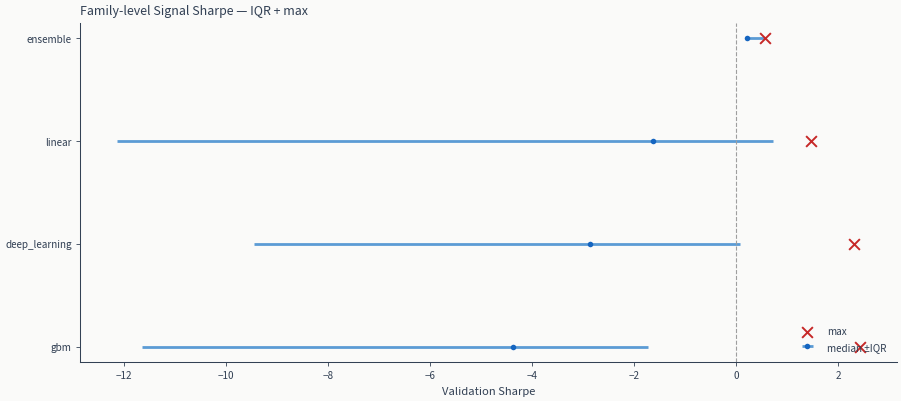

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
fams = family_summary["family"].to_list()
y = np.arange(len(fams))
medians = family_summary["sharpe_median"].to_numpy()
q25 = family_summary["sharpe_q25"].to_numpy()
q75 = family_summary["sharpe_q75"].to_numpy()
maxima = family_summary["sharpe_max"].to_numpy()

ax.errorbar(
    medians,
    y,
    xerr=[medians - q25, q75 - medians],
    fmt="o",
    color="#1565C0",
    ecolor="#5B9BD5",
    elinewidth=2.0,
    capsize=4,
    label="median ±IQR",
)
ax.scatter(maxima, y, marker="x", color="#C62828", s=60, label="max", zorder=5)
ax.axvline(0, color="#9E9E9E", linewidth=0.8, linestyle="--")
ax.set_yticks(y)
ax.set_yticklabels(fams)
ax.set_xlabel("Validation Sharpe")
ax.set_title("Family-level Signal Sharpe — IQR + max")
ax.invert_yaxis()
ax.legend(loc="lower right", frameon=False)
show_with_alt(
    fig,
    "Horizontal chart of validation Sharpe by model family. One row per family, named on "
    "the vertical axis which runs top to bottom. A filled circle marks that family's "
    "median Sharpe with a horizontal bar spanning its interquartile range, and a red "
    "cross marks its single best configuration. A dashed vertical line sits at zero "
    "Sharpe. The gap between a family's median and its cross is the spread the best draw "
    "was taken from.",
)

**How to read the family distribution.** The bars show each family's spread of
validation outcomes, not one number per family. That is deliberate: the sweep
ran many configurations per family, so a family's best result is the maximum of
a sample, and maxima grow with sample size whether or not the family has an
edge.

Compare the medians to compare families, and read the width of each band as
what separates a configuration from its neighbours. Where the bands overlap
heavily, the families are producing the same range of outcomes and the ordering
of their maxima is not evidence that one is better.

The cost model charged here is the engine's, applied identically to every
configuration, so differences between families are not differences in what they
were charged. Every row is on one universe for the same reason.

The lineage gives one backtest per pipeline stage for this prediction. Each
stage's stored interval is pulled alongside it so the change from one stage to
the next can be read against the uncertainty in each.

In [9]:
lineage = explorer.champion_lineage(TOP_PHASH)
ci_lo: dict[str, float] = {}
ci_hi: dict[str, float] = {}
for stage_name, info in lineage.items():
    bm = load_backtest_metrics(CASE_STUDY, backtest_hash=info["backtest_hash"])
    if not bm.is_empty():
        row = bm.row(0, named=True)
        ci_lo[stage_name] = row.get("sharpe_ci95_lo")
        ci_hi[stage_name] = row.get("sharpe_ci95_hi")

print("Lineage stages present for selected prediction:")
for s, info in lineage.items():
    lo, hi = ci_lo.get(s), ci_hi.get(s)
    print(f"  {s}: hash={info['backtest_hash']}, Sharpe={_fmt_ci(info['sharpe'], lo, hi)}")

missing_stages = [s for s in ("cost_sensitivity", "risk_overlay") if s not in lineage]
if missing_stages:
    print()
    print(f"Stage transitions not run for this prediction: {missing_stages}")

Lineage stages present for selected prediction:
  signal: hash=a2d22880e93f, Sharpe=2.416 [1.011, 4.123]
  cost_sensitivity: hash=9447e46c4080, Sharpe=-8.295 [-14.783, -2.457]

Stage transitions not run for this prediction: ['risk_overlay']


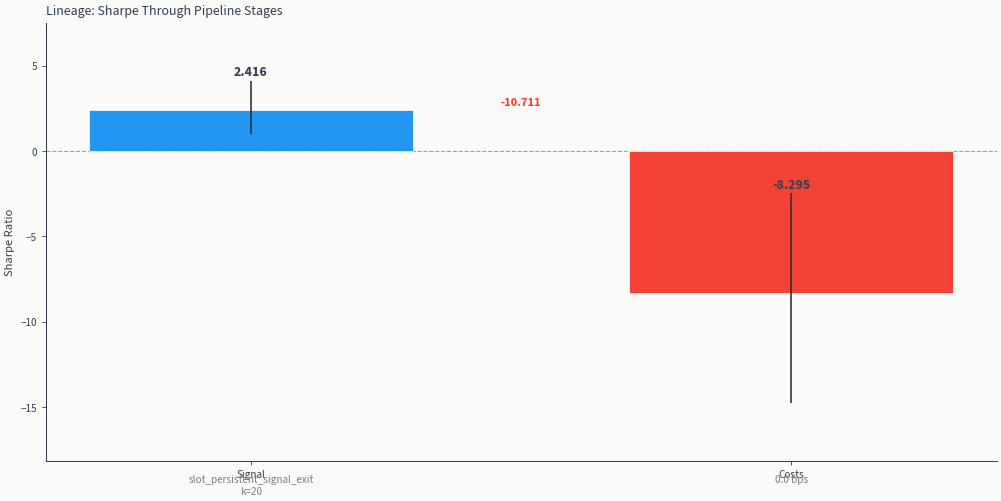

In [10]:
fig = plot_sharpe_waterfall(lineage, ci_lo=ci_lo, ci_hi=ci_hi)
show_with_alt(
    fig,
    "Waterfall of Sharpe across the selected configuration's locked lineage: signal, then "
    "allocation, then cost, then risk overlay, one bar per stage in that order. Each bar carries "
    "asymmetric error bars for its block-bootstrap 95 percent confidence interval. Those are "
    "marginal intervals on each stage and not a test between stages: whether one stage differs "
    "from the next is the paired difference printed below the figure, which can exclude zero "
    "while two bars overlap.",
)

Stage transitions are read from the stored paired comparisons rather than
recomputed here. A stage registered against a different prediction set has no
transition for this lineage, and is reported as not run rather than
reconstructed from unpaired numbers.

In [11]:
ALLOC_HASH = lineage.get("allocation", {}).get("backtest_hash")
if ALLOC_HASH is not None:
    pair = load_paired_metrics(
        CASE_STUDY,
        challenger_hash=ALLOC_HASH,
        benchmark_kind="signal_leader",
    )
    if not pair.is_empty():
        r = pair.row(0, named=True)
        print("Stage transition: allocation challenger vs signal leader")
        print(
            f"  sharpe_diff = "
            f"{_fmt_ci(r['sharpe_diff'], r['sharpe_diff_ci95_lo'], r['sharpe_diff_ci95_hi'])}"
        )
        print(f"  p_value = {r['p_value']:.3f}")
        print(f"  prob_challenger_wins = {r['prob_challenger_wins']:.3f}")
        print(f"  CI status: {ci_status(r['sharpe_diff_ci95_lo'], r['sharpe_diff_ci95_hi'])}")

Live values for the stage transitions printed above are read from
`backtest_paired_metrics`. On this CS, every stage delta is small in
magnitude — the position-level overlays do not produce a stage-delta
CI that excludes zero on the positive side. The signal economics
remain the binding constraint; allocator choice and overlay choice
modulate the magnitude of loss rather than producing a credibility-
resolved positive transition.

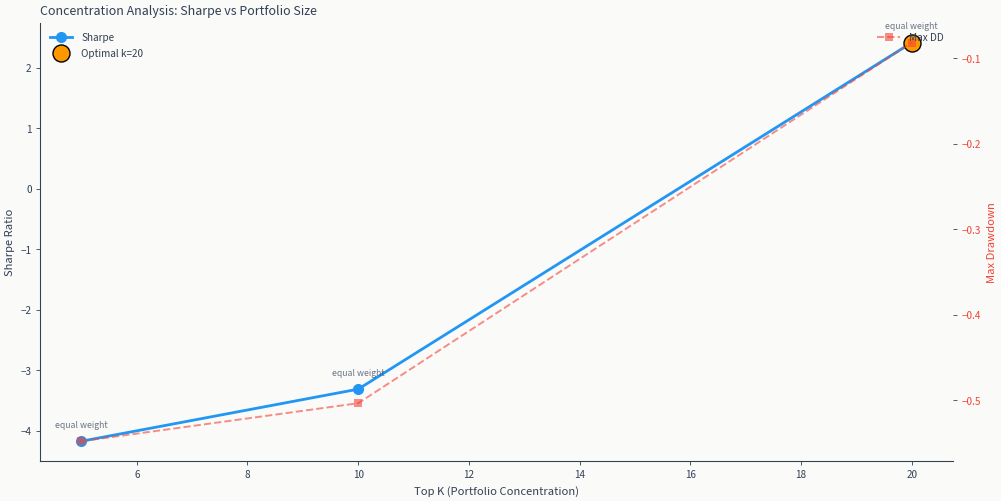

Concentration sweep: best Sharpe by top_k:
shape: (3, 4)
┌───────┬──────────────┬───────────┬──────────────┐
│ top_k ┆ allocator    ┆ sharpe    ┆ max_drawdown │
│ ---   ┆ ---          ┆ ---       ┆ ---          │
│ i64   ┆ str          ┆ f64       ┆ f64          │
╞═══════╪══════════════╪═══════════╪══════════════╡
│ 5     ┆ equal_weight ┆ -4.174535 ┆ -0.547755    │
│ 10    ┆ equal_weight ┆ -3.313624 ┆ -0.503318    │
│ 20    ┆ equal_weight ┆ 2.415932  ┆ -0.081785    │
└───────┴──────────────┴───────────┴──────────────┘


In [12]:
# top_k is an entry-scheme parameter, so the sweep that varies it registers at
# stage=signal on this case study: the carrier's rows are 5, 10 and 20 positions
# there and none at the allocation stage, which `concentration_curve` defaults to.
# Asking for the default raised rather than returning nothing, which is the point
# of that refusal: this cell printed "no concentration data" and dropped its
# figure for as long as the registry held no rows for the carrier at all.
conc_df = explorer.concentration_curve(TOP_PHASH, stage="signal")
if not conc_df.is_empty():
    fig = plot_concentration_curve(conc_df)
    show_with_alt(
        fig,
        "Line chart of Sharpe against portfolio concentration. The horizontal axis is the "
        "number of positions held, top_k, and the vertical axis is the Sharpe the selected "
        "prediction achieves at each. The shape rather than any single point is the content: "
        "it shows whether concentrating the book helped or hurt.",
    )
    best_per_k = conc_df.sort("sharpe", descending=True).group_by("top_k").first().sort("top_k")
    print("Concentration sweep: best Sharpe by top_k:")
    print(best_per_k.select("top_k", "allocator", "sharpe", "max_drawdown"))
else:
    print("No concentration data: no top_k sweep registered for this prediction.")

**How to read the concentration curve.** Position count trades two things off
against each other. Holding few names concentrates capital into the ordering's
strongest views, so a correct ordering is rewarded more and an incorrect one
punished more, and each name turns over more often as the ranking shifts.
Holding many names dilutes both, and as the count approaches the size of the
universe the portfolio converges on the universe itself, leaving nothing for
the ordering to express.

The useful reading is the shape rather than the maximum. A curve with a clear
interior peak says breadth is a real decision for this strategy. A flat curve
says the ordering is not strong enough for concentration to matter, and the
apparent best count is picking out noise.

## §3 Headline performance with uncertainty

The selected specification is the validation-window backtest associated
with the highest baseline Sharpe. Every metric is reported with
its block-bootstrap interval from `backtest_metrics`; the equity overlay
shows the cumulative trajectory against the equal-weight NASDAQ-100
universe benchmark.

In [13]:
full = load_backtest_metrics(CASE_STUDY, backtest_hash=TOP_HASH).row(0, named=True)
full = dict(full)  # mutate-friendly

_db = CASE_DIR / "run_log" / "registry.db"
_cohort_leader_hash = None
_cohort_leader_sharpe = None
_cohort_stage = None
with sqlite3.connect(str(_db)) as _con:
    _stage_for_rank1 = _con.execute(
        "SELECT stage FROM backtest_runs WHERE backtest_hash = ?",
        (TOP_HASH,),
    ).fetchone()[0]
for _try_stage in dict.fromkeys((_stage_for_rank1, "allocation", "signal")):
    with sqlite3.connect(str(_db)) as _con:
        _cohort = _con.execute(
            """
            SELECT dsr_er, dsr_er_pvalue, expected_max_sharpe_er,
                   min_trl_periods_er, dsr_mp, dsr_mp_pvalue,
                   expected_max_sharpe_mp, min_trl_periods_mp,
                   dsr_raw, dsr_raw_pvalue,
                   expected_max_sharpe_raw, min_trl_periods_raw,
                   n_trials_effective_mp, n_trials_effective_er,
                   pbo, pbo_n_combinations, pbo_n_folds,
                   k_variants, leader_hash, leader_sharpe
            FROM cohort_metrics
            WHERE cohort_type='family' AND stage=? AND label=? AND family=?
              AND leader_sharpe IS NOT NULL
            """,
            (_try_stage, RANK1_LABEL, RANK1_FAMILY),
        ).fetchone()
    if _cohort is not None:
        (
            full["dsr_er"],
            full["dsr_er_pvalue"],
            full["expected_max_sharpe_er"],
            full["min_trl_periods_er"],
            full["dsr_mp"],
            full["dsr_mp_pvalue"],
            full["expected_max_sharpe_mp"],
            full["min_trl_periods_mp"],
            full["dsr_raw"],
            full["dsr_raw_pvalue"],
            full["expected_max_sharpe_raw"],
            full["min_trl_periods_raw"],
            full["n_trials_effective_mp"],
            full["n_trials_effective_er"],
            full["pbo"],
            full["pbo_n_combinations"],
            full["pbo_n_folds"],
            full["k_variants"],
            _cohort_leader_hash,
            _cohort_leader_sharpe,
        ) = _cohort
        _cohort_stage = _try_stage
        # Mirror DSR_ER onto the legacy `dsr` / `dsr_pvalue` / `expected_max_sharpe`
        # fields so downstream consumers that still read those keys see the
        # ER-default values.
        full["dsr"] = full["dsr_er"]
        full["dsr_pvalue"] = full["dsr_er_pvalue"]
        full["expected_max_sharpe"] = full["expected_max_sharpe_er"]
        full["min_trl_periods"] = full["min_trl_periods_er"]
        break

spec_block = {
    "case_study": CASE_STUDY,
    "family": RANK1_FAMILY,
    "config_name": RANK1_CONFIG,
    "label": RANK1_LABEL,
    "signal_method": lineage["signal"].get("signal_method"),
    "top_k": lineage["signal"].get("top_k"),
    "allocation": lineage.get("allocation", {}).get("allocator"),
    "risk_overlay": lineage.get("risk_overlay", {}).get("risk_name"),
    "rebalance_step_bars": setup["labels"]["rebalance_step"][RANK1_LABEL],
    "cost_assumption": "engine cost model: 5 bps commission + 2 bps slippage at the baseline stage; per_share_plus_spread sensitivity in §5",
    "validation_window_periods": int(full["n_periods"]) if full["n_periods"] is not None else None,
    "num_trades": int(full["num_trades"]) if full["num_trades"] is not None else None,
    "avg_turnover": full["avg_turnover"],
    "bootstrap_block_length": int(full["bootstrap_block_length"])
    if full["bootstrap_block_length"] is not None
    else None,
    "bootstrap_n": int(full["bootstrap_n"]) if full["bootstrap_n"] is not None else None,
}
print("Rank-1 specification (cross-stage selection, validation window):")
for k, v in spec_block.items():
    print(f"  {k}: {v}")

_block = int(full["bootstrap_block_length"])
_rstep = setup["labels"]["rebalance_step"][RANK1_LABEL]
print(
    f"  audit: bootstrap_block_length={_block} day(s); "
    f"rebalance_step={_rstep} bar(s) ({_rstep * 15} minutes)"
)

# Cohort cascade audit: surface where DSR comes from when the selected lineage
# stage's cohort row is missing.
if _cohort_stage and _cohort_stage != _stage_for_rank1:
    print(
        f"  cohort cascade: selected stage `{_stage_for_rank1}` has no "
        f"cohort_metrics row (cross-stage timestamp-alignment limit); "
        f"DSR/EMS/MinTRL/PBO sourced from family cohort `{_cohort_stage}/"
        f"{RANK1_LABEL}/{RANK1_FAMILY}` (k={int(full['k_variants'])}, "
        f"leader_hash={_cohort_leader_hash}, leader_sharpe="
        f"{_cohort_leader_sharpe:+.3f}; spine sibling differs by "
        f"{full['sharpe'] - _cohort_leader_sharpe:+.3f})."
    )
elif _cohort_stage:
    print(
        f"  cohort: family cohort `{_cohort_stage}/{RANK1_LABEL}/"
        f"{RANK1_FAMILY}` (k={int(full['k_variants'])}, leader_hash="
        f"{_cohort_leader_hash}); spine sibling differs by "
        f"{full['sharpe'] - _cohort_leader_sharpe:+.3f}."
    )

Rank-1 specification (cross-stage selection, validation window):
  case_study: nasdaq100_microstructure
  family: gbm
  config_name: default_multiclass
  label: fwd_dir_15m
  signal_method: slot_persistent_signal_exit
  top_k: 20
  allocation: None
  risk_overlay: None
  rebalance_step_bars: 1
  cost_assumption: engine cost model: 5 bps commission + 2 bps slippage at the baseline stage; per_share_plus_spread sensitivity in §5
  validation_window_periods: 253
  num_trades: 900
  avg_turnover: 0.03873517786561264
  bootstrap_block_length: 6
  bootstrap_n: 1000
  audit: bootstrap_block_length=6 day(s); rebalance_step=1 bar(s) (15 minutes)
  cohort: family cohort `signal/fwd_dir_15m/gbm` (k=462, leader_hash=a2d22880e93f); spine sibling differs by +0.000.


In [14]:
def _row(metric: str, point: str, lo: str, hi: str, status: str) -> dict:
    return {"metric": metric, "point": point, "ci95_lo": lo, "ci95_hi": hi, "status": status}


sharpe_status = ci_status(full["sharpe_ci95_lo"], full["sharpe_ci95_hi"])
sortino_status = ci_status(full["sortino_ci95_lo"], full["sortino_ci95_hi"])
ann_status = ci_status(full["ann_return_ci95_lo"], full["ann_return_ci95_hi"])
mdd_status = ci_status(full["max_dd_ci95_lo"], full["max_dd_ci95_hi"])
calmar_status = ci_status(full["calmar_ci95_lo"], full["calmar_ci95_hi"])

headline = pl.DataFrame(
    [
        _row(
            "Sharpe",
            _fmt(full["sharpe"]),
            _fmt(full["sharpe_ci95_lo"]),
            _fmt(full["sharpe_ci95_hi"]),
            sharpe_status,
        ),
        _row(
            "Sortino",
            _fmt(full["sortino"]),
            _fmt(full["sortino_ci95_lo"]),
            _fmt(full["sortino_ci95_hi"]),
            sortino_status,
        ),
        _row(
            "Annualized return",
            _fmt(full["cagr"]),
            _fmt(full["ann_return_ci95_lo"]),
            _fmt(full["ann_return_ci95_hi"]),
            ann_status,
        ),
        _row(
            "Max drawdown",
            _fmt(full["max_drawdown"]),
            _fmt(full["max_dd_ci95_lo"]),
            _fmt(full["max_dd_ci95_hi"]),
            mdd_status,
        ),
        _row(
            "Calmar",
            _fmt(full["calmar"]),
            _fmt(full["calmar_ci95_lo"]),
            _fmt(full["calmar_ci95_hi"]),
            calmar_status,
        ),
        {
            "metric": "PSR p-value (H0: SR≤0)",
            "point": _fmt(full["psr_pvalue"]),
            "ci95_lo": "—",
            "ci95_hi": "—",
            "status": "n/a",
        },
        {
            "metric": "DSR_ER (selection-adjusted)",
            "point": _fmt(full.get("dsr_er")),
            "ci95_lo": "—",
            "ci95_hi": "—",
            "status": "n/a",
        },
        {
            "metric": "DSR_ER p-value",
            "point": _fmt(full.get("dsr_er_pvalue")),
            "ci95_lo": "—",
            "ci95_hi": "—",
            "status": "n/a",
        },
        {
            "metric": "DSR_MP",
            "point": _fmt(full.get("dsr_mp")),
            "ci95_lo": "—",
            "ci95_hi": "—",
            "status": "n/a",
        },
        {
            "metric": "DSR_MP p-value",
            "point": _fmt(full.get("dsr_mp_pvalue")),
            "ci95_lo": "—",
            "ci95_hi": "—",
            "status": "n/a",
        },
        {
            "metric": "DSR_RAW (naive raw-K)",
            "point": _fmt(full.get("dsr_raw")),
            "ci95_lo": "—",
            "ci95_hi": "—",
            "status": "n/a",
        },
        {
            "metric": "DSR_RAW p-value",
            "point": _fmt(full.get("dsr_raw_pvalue")),
            "ci95_lo": "—",
            "ci95_hi": "—",
            "status": "n/a",
        },
        {
            "metric": (
                f"Expected max Sharpe (k={int(full['k_variants'])})"
                if full.get("k_variants") is not None
                else "Expected max Sharpe"
            ),
            "point": _fmt(full.get("expected_max_sharpe_er")),
            "ci95_lo": "—",
            "ci95_hi": "—",
            "status": "n/a",
        },
        {
            "metric": "PBO (CSCV)",
            "point": _fmt(full.get("pbo"), ".3f"),
            "ci95_lo": "—",
            "ci95_hi": "—",
            "status": "n/a",
        },
    ]
)
print("Rank-1 headline metrics with 95% CIs:")
print(headline)

Rank-1 headline metrics with 95% CIs:
shape: (14, 5)
┌─────────────────────────────┬─────────┬─────────┬─────────┬──────────────────────┐
│ metric                      ┆ point   ┆ ci95_lo ┆ ci95_hi ┆ status               │
│ ---                         ┆ ---     ┆ ---     ┆ ---     ┆ ---                  │
│ str                         ┆ str     ┆ str     ┆ str     ┆ str                  │
╞═════════════════════════════╪═════════╪═════════╪═════════╪══════════════════════╡
│ Sharpe                      ┆ 2.4159  ┆ 1.0111  ┆ 4.1232  ┆ excludes_zero_strong │
│ Sortino                     ┆ 3.7547  ┆ 1.4668  ┆ 7.0939  ┆ excludes_zero_strong │
│ Annualized return           ┆ 0.6298  ┆ 0.2209  ┆ 1.2773  ┆ excludes_zero_strong │
│ Max drawdown                ┆ -0.0818 ┆ -0.1541 ┆ -0.0524 ┆ excludes_zero_strong │
│ Calmar                      ┆ 7.7003  ┆ 1.5822  ┆ 20.5863 ┆ excludes_zero_strong │
│ …                           ┆ …       ┆ …       ┆ …       ┆ …                    │
│ DSR_MP p-v

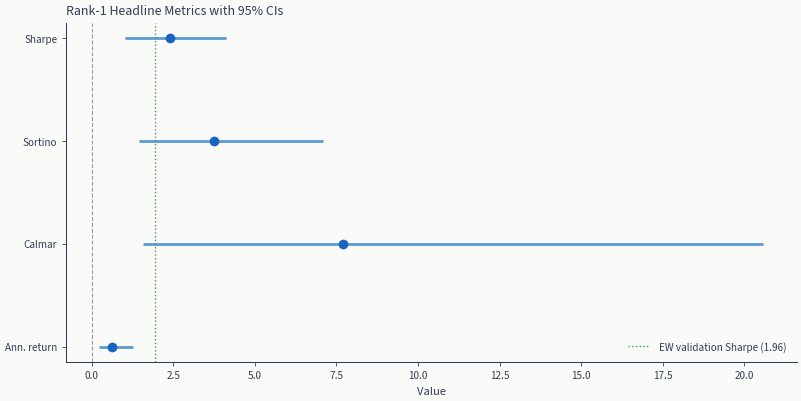

In [15]:
# Forest plot: selected-lineage metrics with CI bars + reference lines
ew_val = load_benchmark_metrics(CASE_STUDY, PRIMARY_LABEL, period="validation")
forest_metrics = [
    ("Sharpe", full["sharpe"], full["sharpe_ci95_lo"], full["sharpe_ci95_hi"]),
    ("Sortino", full["sortino"], full["sortino_ci95_lo"], full["sortino_ci95_hi"]),
    ("Calmar", full["calmar"], full["calmar_ci95_lo"], full["calmar_ci95_hi"]),
    ("Ann. return", full["cagr"], full["ann_return_ci95_lo"], full["ann_return_ci95_hi"]),
]

fig, ax = plt.subplots(figsize=(8, 4))
y = np.arange(len(forest_metrics))
points = np.array([m[1] for m in forest_metrics])
los = np.array([m[2] for m in forest_metrics])
his = np.array([m[3] for m in forest_metrics])
ax.errorbar(
    points,
    y,
    xerr=[points - los, his - points],
    fmt="o",
    color="#1565C0",
    ecolor="#5B9BD5",
    elinewidth=2.0,
    capsize=4,
    markersize=7,
)
ax.axvline(0, color="#9E9E9E", linestyle="--", linewidth=0.8)
ax.axvline(
    ew_val["sharpe"],
    color="#43A047",
    linestyle=":",
    linewidth=1.0,
    label=f"EW validation Sharpe ({ew_val['sharpe']:.2f})",
)
_alloc_sharpe = lineage.get("allocation", {}).get("sharpe")
if _alloc_sharpe is not None:
    ax.axvline(
        _alloc_sharpe,
        color="#E53935",
        linestyle=":",
        linewidth=1.0,
        label=f"Allocation selection Sharpe ({_alloc_sharpe:.2f})",
    )
ax.set_yticks(y)
ax.set_yticklabels([m[0] for m in forest_metrics])
ax.invert_yaxis()
ax.set_xlabel("Value")
ax.set_title("Rank-1 Headline Metrics with 95% CIs")
ax.legend(loc="lower right", fontsize=8, frameon=False)
show_with_alt(
    fig,
    "Forest plot of the selected configuration's headline metrics. One row per metric, named on "
    "the vertical axis, with a point estimate and a horizontal bar for its 95 percent confidence "
    "interval, read on a shared horizontal value axis. A dashed vertical line marks zero, and "
    "further vertical reference lines mark the equal-weight validation Sharpe and the "
    "allocation-stage Sharpe. Those two lines are Sharpe values, so only the Sharpe row is "
    "comparable with them; the Sortino, Calmar and annualized-return rows share the axis but "
    "measure different quantities.",
)

The strategy's returns are stored daily while the benchmark is stored at the
decision cadence, so the benchmark is aggregated to daily before the two are
aligned. Comparing series at different frequencies would otherwise pair a day
against a fraction of one.

Validation overlay window: 2020-06-30 → 2021-06-30, n=253


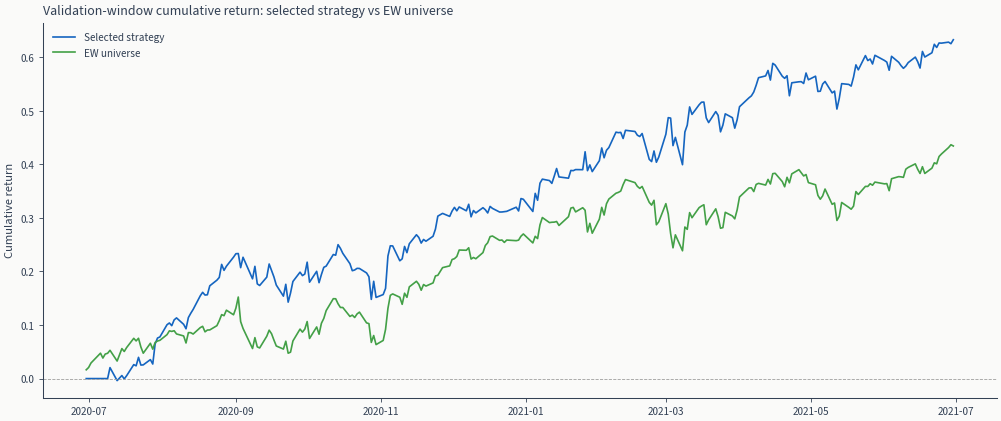

In [16]:
strat_returns_path = CASE_DIR / "run_log" / "backtest" / TOP_HASH / "daily_returns.parquet"
strat_df = (
    pl.read_parquet(strat_returns_path)
    .sort("timestamp")
    .with_columns(pl.col("timestamp").cast(pl.Date).alias("ts"))
    .select(pl.col("ts"), pl.col("daily_return").alias("strategy"))
)

bench_val = (
    load_benchmark_returns(CASE_STUDY, PRIMARY_LABEL, period="validation")
    .with_columns(pl.col("timestamp").cast(pl.Date).alias("ts"))
    .group_by("ts")
    .agg(((1 + pl.col("ew_return")).product() - 1).alias("benchmark"))
    .sort("ts")
)

aligned = strat_df.join(bench_val, on="ts", how="inner").sort("ts")
print(
    f"Validation overlay window: {aligned['ts'].min()} → {aligned['ts'].max()}, n={aligned.height}"
)

cum_strat = np.cumprod(1 + aligned["strategy"].to_numpy()) - 1
cum_bench = np.cumprod(1 + aligned["benchmark"].to_numpy()) - 1
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.plot(aligned["ts"], cum_strat, color="#1565C0", linewidth=1.2, label="Selected strategy")
ax.plot(aligned["ts"], cum_bench, color="#43A047", linewidth=1.2, label="EW universe")
ax.axhline(0, color="#9E9E9E", linewidth=0.6, linestyle="--")
ax.set_ylabel("Cumulative return")
ax.set_title("Validation-window cumulative return: selected strategy vs EW universe")
ax.legend(loc="best", frameon=False)
show_with_alt(
    fig,
    "Two cumulative return paths over the validation window, plotted against time. One "
    "line is the selected strategy and the other the equal-weight universe, distinguished "
    "in the legend; the vertical axis is cumulative return and a dashed horizontal line "
    "marks zero. The comparison is the point: the strategy's path is only informative "
    "beside the universe it traded in.",
)

**How to read the selection-bias adjustment.** The deflated Sharpe ratio asks
what the highest result from a search of this size would look like if none of
the configurations had an edge, and discounts the observed result by that
amount. The more configurations searched, the higher the bar it sets.

Its inputs are the number of variants in the cohort searched, the shape of the
return distribution, and the length of the record. All three are printed above
rather than assumed, because the count of variants in particular decides how
large the adjustment is, and a count that quietly includes duplicates of an
already-chosen configuration inflates the correction.

The companion quantity is the track record length required for a result of this
size to become distinguishable from zero. When it exceeds the history
available, the honest statement is that the window cannot settle the question,
whatever the point estimate.

## §4 Risk and drawdown analysis

Risk metrics use the validation-window strategy returns paired against the validation
EW benchmark. The drawdown panel surfaces the worst episode and whether it recovered;
rolling Sharpe and rolling beta say whether either was steady or driven by part of the
window.

The lower panel is worth reading for its shape and not only its depth: whether the
losses arrived steadily across the window or inside one episode, and whether anything
was recovered afterwards. That is a description of when the strategy lost, and it is as
far as the panel goes. It does not identify a cause - a strategy whose costs exceed its
edge still has winning trades and partial recoveries, and a steady decline can happen
with no cost at all - so §5 varies the cost directly rather than inferring it from this
curve.

In [17]:
strat_arr = aligned["strategy"].to_numpy()
bench_arr = aligned["benchmark"].to_numpy()
ts_arr = aligned["ts"].to_list()

pa = PortfolioAnalysis(
    returns=strat_arr,
    benchmark=bench_arr,
    dates=ts_arr,
    periods_per_year=PERIODS_PER_YEAR,
)

dd = pa.compute_drawdown_analysis()
print("Drawdown analysis (validation window):")
print(dd)

Drawdown analysis (validation window):
DrawdownResult(current_drawdown=0.0, max_drawdown=-0.08178547952266418, avg_drawdown=-0.027961981792336672, underwater_curve=shape: (253,)
Series: 'drawdown' [f64]
[
	0.0
	0.0
	0.0
	0.0
	0.0
	…
	0.0
	-0.000191
	0.0
	-0.001788
	0.0
], top_drawdowns=[DrawdownPeriod(peak_date=datetime.date(2020, 10, 14), valley_date=datetime.date(2020, 10, 28), recovery_date=datetime.date(2020, 11, 13), depth=np.float64(-0.08178547952266418), duration_days=10, recovery_days=12), DrawdownPeriod(peak_date=datetime.date(2020, 9, 2), valley_date=datetime.date(2020, 9, 23), recovery_date=datetime.date(2020, 10, 14), depth=np.float64(-0.07359684508195691), duration_days=14, recovery_days=15), DrawdownPeriod(peak_date=datetime.date(2021, 3, 2), valley_date=datetime.date(2021, 3, 8), recovery_date=datetime.date(2021, 3, 11), depth=np.float64(-0.05909245038279657), duration_days=4, recovery_days=3), DrawdownPeriod(peak_date=datetime.date(2021, 4, 15), valley_date=datetime.dat

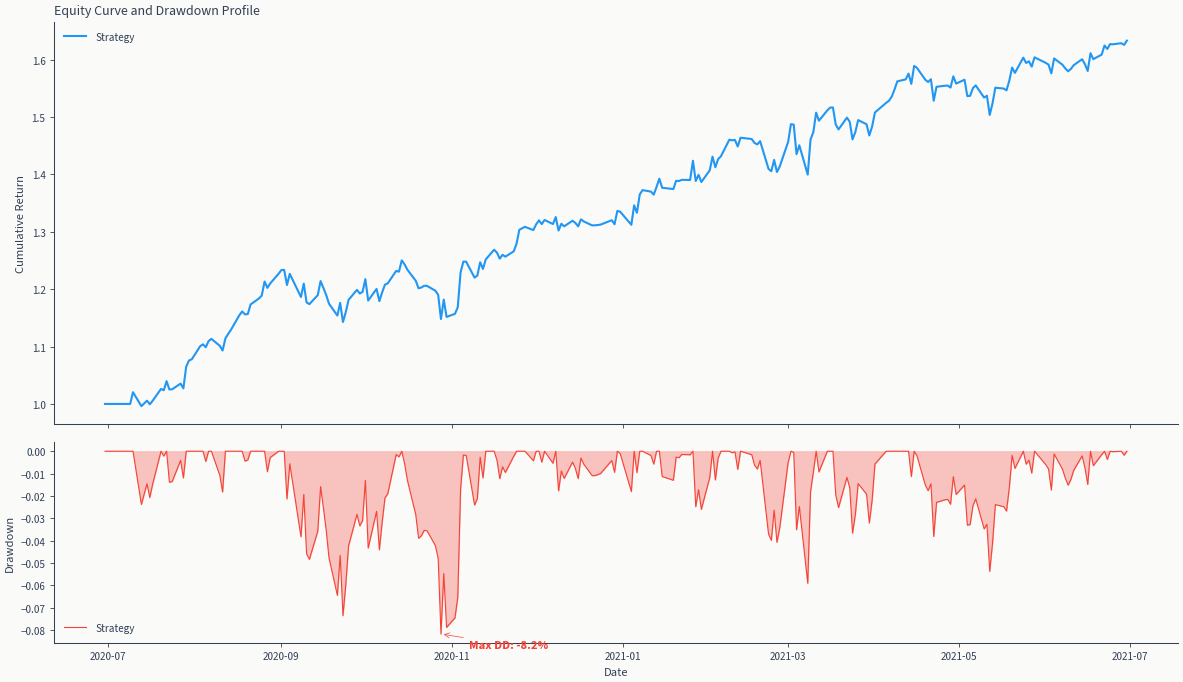

In [18]:
fig = plot_equity_drawdown(strat_returns_path)
show_with_alt(
    fig,
    "Two stacked panels sharing a time axis. The upper panel is the selected strategy's "
    "cumulative return over the window and the lower panel is its drawdown, the distance "
    "below the running maximum at each moment. Reading a date down both panels pairs a "
    "level of return with the loss being carried to hold it.",
)

In [19]:
# Rolling Sharpe + rolling beta. `aligned` is daily - the strategy's returns are stored
# that way and the benchmark is compounded to match - so the window is 126 trading days,
# about six months of a validation window that runs roughly 253.
ROLL_WINDOW = 126
roll = pa.compute_rolling_metrics(windows=[ROLL_WINDOW], metrics=["sharpe", "beta"])

# Summarised rather than printed as an object. This used to print the types of the
# result's members, which says nothing about the strategy, and the section's own prose
# promises these two series - a computed result that reaches no reader is the same as one
# never computed.
_roll_rows = []
for _label, _store in (("Rolling Sharpe", roll.sharpe), ("Rolling beta", roll.beta)):
    _series = _store.get(ROLL_WINDOW)
    _valid = _series.drop_nulls() if _series is not None else None
    if _valid is None or _valid.len() == 0:
        _roll_rows.append({"series": _label, "n": 0, "min": "n/a", "median": "n/a", "max": "n/a"})
        continue
    _roll_rows.append(
        {
            "series": _label,
            "n": _valid.len(),
            "min": f"{_valid.min():+.3f}",
            "median": f"{_valid.median():+.3f}",
            "max": f"{_valid.max():+.3f}",
        }
    )
print(f"Rolling metrics over {ROLL_WINDOW} trading days ({aligned.height} days in the window):")
print(pl.DataFrame(_roll_rows))

# Tail-risk read straight from registry (already computed and stored)
tail_table = pl.DataFrame(
    [
        {"metric": "Volatility (ann.)", "value": f"{full['volatility']:.4f}"},
        {"metric": "VaR 95% (daily)", "value": f"{full['var_95']:.4f}"},
        {"metric": "CVaR 95% (daily)", "value": f"{full['cvar_95']:.4f}"},
        {"metric": "Tail ratio", "value": f"{full['tail_ratio']:.3f}"},
        {"metric": "Skewness", "value": f"{full['skewness']:.3f}"},
        {"metric": "Kurtosis", "value": f"{full['kurtosis']:.3f}"},
    ]
)
print()
print("Tail risk profile:")
print(tail_table)

Rolling metrics over 126 trading days (253 days in the window):
shape: (2, 5)
┌────────────────┬─────┬────────┬────────┬────────┐
│ series         ┆ n   ┆ min    ┆ median ┆ max    │
│ ---            ┆ --- ┆ ---    ┆ ---    ┆ ---    │
│ str            ┆ i64 ┆ str    ┆ str    ┆ str    │
╞════════════════╪═════╪════════╪════════╪════════╡
│ Rolling Sharpe ┆ 128 ┆ +1.358 ┆ +2.243 ┆ +3.078 │
│ Rolling beta   ┆ 128 ┆ +0.828 ┆ +0.881 ┆ +0.937 │
└────────────────┴─────┴────────┴────────┴────────┘

Tail risk profile:
shape: (6, 2)
┌───────────────────┬─────────┐
│ metric            ┆ value   │
│ ---               ┆ ---     │
│ str               ┆ str     │
╞═══════════════════╪═════════╡
│ Volatility (ann.) ┆ 0.2116  │
│ VaR 95% (daily)   ┆ -0.0220 │
│ CVaR 95% (daily)  ┆ -0.0291 │
│ Tail ratio        ┆ 0.938   │
│ Skewness          ┆ -0.118  │
│ Kurtosis          ┆ 1.051   │
└───────────────────┴─────────┘


In [20]:
fold_df = load_backtest_fold_metrics(CASE_STUDY, backtest_hash=TOP_HASH)
print(f"Per-fold breakdown ({fold_df.height} folds):")
print(fold_df.select("fold_id", "sharpe", "max_drawdown", "n_days"))
print()
print(f"Fold Sharpe range: [{fold_df['sharpe'].min():.3f}, {fold_df['sharpe'].max():.3f}]")
print(f"Fold Sharpe std:   {fold_df['sharpe'].std():.3f}")

Per-fold breakdown (2 folds):
shape: (2, 4)
┌─────────┬──────────┬──────────────┬────────┐
│ fold_id ┆ sharpe   ┆ max_drawdown ┆ n_days │
│ ---     ┆ ---      ┆ ---          ┆ ---    │
│ i64     ┆ f64      ┆ f64          ┆ f64    │
╞═════════╪══════════╪══════════════╪════════╡
│ 0       ┆ 2.712386 ┆ -0.081785    ┆ 128.0  │
│ 1       ┆ 2.236285 ┆ -0.059092    ┆ 126.0  │
└─────────┴──────────┴──────────────┴────────┘

Fold Sharpe range: [2.236, 2.712]
Fold Sharpe std:   0.337


**How to read the four printouts above.** Each answers a question the others cannot,
and none of their values is transcribed here: this notebook re-resolves its carrier from
the registry on every run, so a number written into this cell would describe whichever
configuration was rank-1 the day it was written.

*Per-fold Sharpes* say whether the headline belongs to the strategy or to one block.
Two folds agreeing in sign is weak evidence; two disagreeing is strong evidence against.
With `evaluation.n_splits: 2` there is no third block to break the tie, so a split
verdict is a reason to distrust the headline rather than to average it.

*Skewness and kurtosis* say what the distribution behind that Sharpe looks like.
Negative skew with high kurtosis is the shape a Sharpe flatters, because Sharpe reads
only the first two moments: many small gains against occasional large losses. Positive
skew is the opposite trade, and it is what a strategy paying a per-trade cost for
occasional large wins looks like.

*Tail ratio* is the 95th percentile over the absolute 5th, so it compares where the two
tails begin and not how much sits beyond those points. Near 1 the two boundaries are the
same size. It answers a different question from skewness, which the extremes past those
percentiles drive, so the two can point opposite ways on the same series - rare large
losses pull the skew negative while leaving the 5th percentile where it was. Disagreement
between them is a fact about the distribution rather than a sign that one is wrong.

*The rolling window* locates the result in time: each point is the Sharpe of the 126
trading days ending there, so the summary reports how far the estimate moved over the
window rather than a single number for the whole period. Read the spread between the
minimum and the maximum, not the sign. Consecutive windows share 125 of their 126 days,
so the series is autocorrelated by construction, and a validation window of roughly 253
days holds about two non-overlapping windows. Sampling variation alone produces sign
changes on a stationary series at this length, so a crossing is not evidence of a
regime, and an estimate that stays positive throughout does not establish that
performance was stable. Rolling beta is read the same way and carries the same
qualification: each point is an estimate over 126 overlapping days, and a book whose
population beta is zero still returns nonzero sample betas.

Dollar neutrality and benchmark beta are two different properties and only one of them is
estimated. Dollar neutrality is a fact about the weights - whether the long and short
notionals sum to zero - and is read off the allocation directly. Beta is a fact about how
those positions co-move with the benchmark, so a book can be exactly dollar-neutral and
still carry beta whenever its longs and shorts differ in benchmark sensitivity. Rolling
beta is the estimate of that second quantity, and a wandering series is a reason to
measure the exposure with its uncertainty rather than a reading of it.

## §5 Friction budget & cost sensitivity

Cost sensitivity is where a short-rebalancing strategy is decided, because
every cost is charged per trade and this one trades often. Two grids are read
here: a **cost grid** that walks commission and slippage from zero upward, and
a **risk-overlay grid** of rules that close a position on a condition other
than the signal.

They answer different questions. The cost grid asks how much friction the
strategy can absorb before its edge runs out, which states the execution
quality it requires rather than the profit it made under one assumption. The
overlay grid asks whether trading *less* on positions that are going wrong
preserves more than the extra trading costs. The two were swept independently,
with overlays applied at zero engine cost, so each result is attributable to
the field its sweep varied.

**Neither grid is restricted to the selected lineage, and they do not sit on
the same universe.** Both read their whole stage across labels, which is what
the per-horizon stratification below is for. The cost rows come from
`17_costs`, whose pool is pinned to the canonical `cost_feasible` universe; the
overlay rows come from `16_risk_management`, which overlays allocation-stage
specs that carry no `universe_filter` and are therefore full-universe. So a
cost curve and an overlay row in this section are not two readings of one
portfolio, and the gradient across thresholds is what §5.2 supports rather than
a level comparable with §5.1.

### §5.1 Cost sensitivity stratified by label horizon

In [21]:
with sqlite3.connect(str(_db)) as _con:
    cost_df = pl.DataFrame(
        _con.execute(
            """
            SELECT
                b.spec_json,
                t.family,
                t.config_name,
                t.label,
                bm.sharpe,
                bm.sharpe_ci95_lo,
                bm.sharpe_ci95_hi,
                bm.max_drawdown,
                bm.cagr,
                bm.num_trades,
                bm.avg_turnover
            FROM backtest_runs b
            JOIN backtest_metrics bm ON bm.backtest_hash  = b.backtest_hash
            JOIN prediction_sets p   ON b.prediction_hash = p.prediction_hash
            JOIN training_runs t     ON p.training_hash   = t.training_hash
            WHERE b.stage = 'cost_sensitivity'
              AND p.split = 'validation'
              AND bm.sharpe IS NOT NULL
              AND (bm.num_trades IS NULL OR bm.num_trades > 0)
            """
        ).fetchall(),
        schema=[
            "spec_json",
            "family",
            "config_name",
            "label",
            "sharpe",
            "sharpe_ci95_lo",
            "sharpe_ci95_hi",
            "max_drawdown",
            "cagr",
            "num_trades",
            "avg_turnover",
        ],
        orient="row",
    )


def _cost_bps(spec_str: str) -> float:
    """Cost per leg in bps from the locked spec.

    `backtest_config.commission.rate` and `backtest_config.slippage.rate`
    are decimal fractions; sum × 10000 gives total per-leg cost in bps.
    """
    spec = json.loads(spec_str)
    bc = spec.get("backtest_config", {})
    comm = bc.get("commission", {}) or {}
    slip = bc.get("slippage", {}) or {}
    return float((comm.get("rate", 0) + slip.get("rate", 0)) * 10000)


cost_df = cost_df.with_columns(
    pl.col("spec_json").map_elements(_cost_bps, return_dtype=pl.Float64).alias("cost_bps")
)

# Aggregate per (label, cost_bps): max-config Sharpe + envelope
cost_curve_per_label = (
    cost_df.group_by(["label", "cost_bps"])
    .agg(
        n=pl.len(),
        sharpe_max=pl.col("sharpe").max(),
        sharpe_min=pl.col("sharpe").min(),
        sharpe_median=pl.col("sharpe").median(),
        # CI lower bound *of the best-Sharpe row* per (label, cost):
        # this is the credibility band on the headline cell.
        best_ci_lo=pl.col("sharpe_ci95_lo").top_k_by("sharpe", 1).first(),
        best_ci_hi=pl.col("sharpe_ci95_hi").top_k_by("sharpe", 1).first(),
        best_n_trades=pl.col("num_trades").top_k_by("sharpe", 1).first(),
        best_avg_turnover=pl.col("avg_turnover").top_k_by("sharpe", 1).first(),
        best_family=pl.col("family").top_k_by("sharpe", 1).first(),
        best_config=pl.col("config_name").top_k_by("sharpe", 1).first(),
    )
    .sort(["label", "cost_bps"])
)
print("Per-label cost grid (validation, best Sharpe per (label, cost) cell):")
with pl.Config(tbl_rows=33):
    print(
        cost_curve_per_label.select(
            [
                "label",
                "cost_bps",
                "sharpe_max",
                "best_ci_lo",
                "best_ci_hi",
                "sharpe_median",
                "best_n_trades",
                "best_family",
                "best_config",
            ]
        )
    )

Per-label cost grid (validation, best Sharpe per (label, cost) cell):
shape: (13, 9)
┌───────────┬──────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ label     ┆ cost_bps ┆ sharpe_ma ┆ best_ci_l ┆ … ┆ sharpe_me ┆ best_n_tr ┆ best_fami ┆ best_conf │
│ ---       ┆ ---      ┆ x         ┆ o         ┆   ┆ dian      ┆ ades      ┆ ly        ┆ ig        │
│ str       ┆ f64      ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---       │
│           ┆          ┆ f64       ┆ f64       ┆   ┆ f64       ┆ f64       ┆ str       ┆ str       │
╞═══════════╪══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ fwd_dir_1 ┆ 0.0      ┆ -8.294795 ┆ -14.78267 ┆ … ┆ -18.00928 ┆ 20646.0   ┆ gbm       ┆ default_m │
│ 5m        ┆          ┆           ┆ 9         ┆   ┆ 3         ┆           ┆           ┆ ulticlass │
│ fwd_dir_1 ┆ 5.0      ┆ -14.46814 ┆ -17.93415 ┆ … ┆ -17.25591 ┆ 94586.0   ┆ gbm       ┆ default_m │
│ 5m  

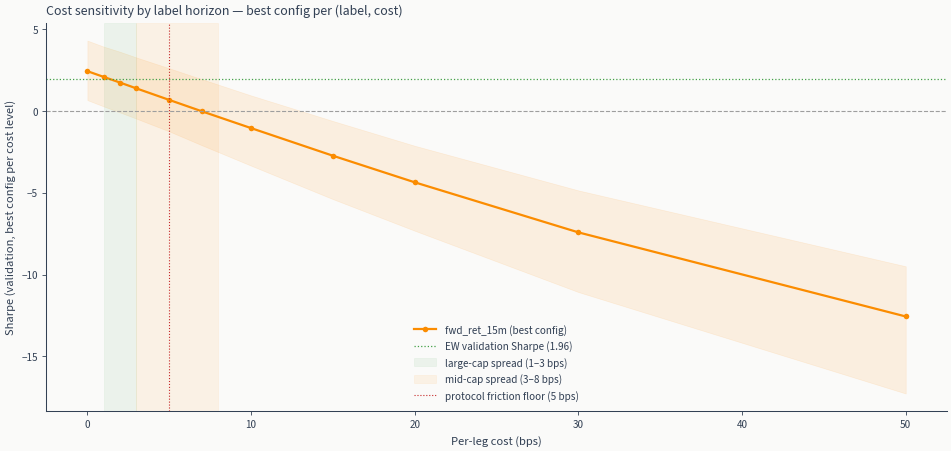

In [22]:
# Per-label cost curve: one line per label horizon
fig, ax = plt.subplots(figsize=(9.5, 4.5))
label_order = ["fwd_ret_5m", "fwd_ret_15m", "fwd_ret_60m"]
label_colors = {
    "fwd_ret_5m": "#C62828",
    "fwd_ret_15m": "#FB8C00",
    "fwd_ret_60m": "#1565C0",
}
for lbl in label_order:
    sub = cost_curve_per_label.filter(pl.col("label") == lbl).sort("cost_bps")
    if sub.is_empty():
        continue
    xs = sub["cost_bps"].to_numpy()
    ax.plot(
        xs,
        sub["sharpe_max"].to_numpy(),
        color=label_colors[lbl],
        linewidth=1.6,
        marker="o",
        markersize=4,
        label=f"{lbl} (best config)",
    )
    ax.fill_between(
        xs,
        sub["best_ci_lo"].to_numpy(),
        sub["best_ci_hi"].to_numpy(),
        color=label_colors[lbl],
        alpha=0.10,
    )

ax.axhline(0, color="#9E9E9E", linewidth=0.8, linestyle="--")
ax.axhline(
    ew_val["sharpe"],
    color="#43A047",
    linewidth=0.9,
    linestyle=":",
    label=f"EW validation Sharpe ({ew_val['sharpe']:.2f})",
)
ax.axvspan(1.0, 3.0, color="#43A047", alpha=0.08, label="large-cap spread (1–3 bps)")
ax.axvspan(3.0, 8.0, color="#FB8C00", alpha=0.08, label="mid-cap spread (3–8 bps)")
ax.axvline(
    5.0, color="#C62828", linewidth=0.8, linestyle=":", label="protocol friction floor (5 bps)"
)
ax.set_xlabel("Per-leg cost (bps)")
ax.set_ylabel("Sharpe (validation, best config per cost level)")
ax.set_title("Cost sensitivity by label horizon — best config per (label, cost)")
ax.legend(loc="best", fontsize=8, frameon=False)
show_with_alt(
    fig,
    "Line chart of validation Sharpe against per-leg cost in basis points, one line per label "
    "horizon, each showing the best configuration at every cost level with a shaded band around "
    "it. A dashed horizontal line marks zero Sharpe. Two shaded vertical spans mark realistic "
    "spreads, roughly 1 to 3 basis points for large caps and 3 to 8 for mid caps, and a dotted "
    "vertical line marks the protocol's 5 basis point friction floor. That floor is a reference "
    "and not what this case study charges: config/setup.yaml bills a per-share commission plus "
    "symbol-specific half-spreads, not a flat rate.",
)

Trade counts at zero cost say how exposed each label is to friction before any
cost is charged. A configuration that trades twice as often loses twice as much
to the same per-trade cost, so this count predicts the slope of each label's
cost curve rather than its level.

In [23]:
turnover_table = (
    cost_df.filter(pl.col("cost_bps") == 0)
    .group_by("label")
    .agg(
        n_configs=pl.len(),
        max_sharpe=pl.col("sharpe").max(),
        median_sharpe=pl.col("sharpe").median(),
        max_num_trades=pl.col("num_trades").max(),
        min_num_trades=pl.col("num_trades").min(),
        median_avg_turnover=pl.col("avg_turnover").median(),
    )
    .sort("median_avg_turnover", descending=True)
)
print("Trade count and turnover at zero cost by label horizon:")
print(turnover_table)

Trade count and turnover at zero cost by label horizon:
shape: (2, 7)
┌─────────────┬───────────┬────────────┬──────────────┬──────────────┬──────────────┬──────────────┐
│ label       ┆ n_configs ┆ max_sharpe ┆ median_sharp ┆ max_num_trad ┆ min_num_trad ┆ median_avg_t │
│ ---         ┆ ---       ┆ ---        ┆ e            ┆ es           ┆ es           ┆ urnover      │
│ str         ┆ u32       ┆ f64        ┆ ---          ┆ ---          ┆ ---          ┆ ---          │
│             ┆           ┆            ┆ f64          ┆ f64          ┆ f64          ┆ f64          │
╞═════════════╪═══════════╪════════════╪══════════════╪══════════════╪══════════════╪══════════════╡
│ fwd_dir_15m ┆ 20        ┆ -8.294795  ┆ -18.009283   ┆ 94584.0      ┆ 11314.0      ┆ 14.928854    │
│ fwd_ret_15m ┆ 1         ┆ 2.441897   ┆ 2.441897     ┆ 3165.0       ┆ 3165.0       ┆ 0.009684     │
└─────────────┴───────────┴────────────┴──────────────┴──────────────┴──────────────┴──────────────┘


Two breakeven costs are reported per label. The first is the highest cost at
which the point estimate stays positive. The second is the highest cost at
which the interval's lower bound stays positive, which is the stricter and more
useful of the two: it is the cost the strategy can absorb and still be
distinguishable from no strategy at all.

In [24]:
def _breakevens(curve: pl.DataFrame) -> dict:
    point_be = curve.filter(pl.col("sharpe_max") > 0)["cost_bps"].max()
    ci_be = curve.filter(pl.col("best_ci_lo") > 0)["cost_bps"].max()
    return {
        "point_estimate_max_bps": point_be,
        "ci_aware_max_bps": ci_be,
    }


print("Breakeven analysis (per-label):")
for lbl in label_order:
    sub = cost_curve_per_label.filter(pl.col("label") == lbl)
    be = _breakevens(sub)
    print(
        f"  {lbl}: point-estimate Sharpe>0 up to {be['point_estimate_max_bps']} bps; "
        f"CI lower bound>0 up to {be['ci_aware_max_bps']} bps"
    )

print()
print("Realistic NQ100 friction (per setup.yaml):")
print(f"  Cost model: {setup['costs'].get('model')}")
print(f"  Per-share commission: ${setup['costs'].get('per_share')}/share")
print(f"  Minimum per trade: ${setup['costs'].get('minimum', 0.0)}")
print(f"  Half-spread source: {setup['costs'].get('asset_spreads_source', 'n/a')}")
print("See Chapter 18 for transaction-cost framework details.")

Breakeven analysis (per-label):
  fwd_ret_5m: point-estimate Sharpe>0 up to None bps; CI lower bound>0 up to None bps
  fwd_ret_15m: point-estimate Sharpe>0 up to 5.0 bps; CI lower bound>0 up to 1.0 bps
  fwd_ret_60m: point-estimate Sharpe>0 up to None bps; CI lower bound>0 up to None bps

Realistic NQ100 friction (per setup.yaml):
  Cost model: per_share_plus_spread
  Per-share commission: $0.0035/share
  Minimum per trade: $0.0
  Half-spread source: liquidity_profile.parquet
See Chapter 18 for transaction-cost framework details.


**How to read the cost surface.** Each row walks one label's lineage across
the cost levels. Two features carry the information.

The value at zero cost is the strategy before friction. If it is not
positive there, no cost assumption rescues it, and the rest of that row is
describing how a losing strategy loses.

Where a row crosses zero is the breakeven cost: the execution quality the
strategy needs to be worth running. That number is comparable against what a
venue and order size actually achieve, which a profit figure computed at one
assumed cost is not.

Read the intervals as well as the points. A row whose interval spans zero at
every cost level has not established its sign anywhere on the grid, and its
apparent breakeven crossing is not a measurement.

The horizons differ in how much friction they can absorb, and the reason is
arithmetic rather than modelling: a longer horizon holds each position over
more time, so the same per-trade cost is spread over a larger expected move.

### §5.2 Risk-overlay sensitivity sweep

The risk_overlay stage applies position-level overlays per label on
top of the base allocation: **trailing stop** (exit a position when
its price retraces a threshold from its high-water mark since entry),
**stop-loss** (exit when unrealized loss exceeds a threshold), and
**time exit** (close a position after a fixed number of bars). Each acts on a
single position and leaves the rest of the book trading.

Portfolio-level halts - a maximum drawdown limit, a daily loss limit - are not
swept here. They stop trading permanently once breached, so a configuration
that trips one produces a truncated return series whose summary statistics are
not comparable with those of a configuration that ran the full window. They
are governance instruments rather than parameters to sweep.

The threshold is what the sweep is really varying. A tight threshold triggers
often, so it pays for its protection frequently and can fire on ordinary
fluctuation rather than on the loss it was meant to catch. A loose threshold
rarely fires, costs little and protects little. The gradient across thresholds
transfers to other strategies; the level of any individual cell does not.

In [25]:
with sqlite3.connect(str(_db)) as _con:
    risk_df = pl.DataFrame(
        _con.execute(
            """
            SELECT
                b.spec_json,
                t.label,
                bm.sharpe,
                bm.sharpe_ci95_lo,
                bm.sharpe_ci95_hi,
                bm.max_drawdown,
                bm.cagr,
                bm.num_trades,
                bm.avg_turnover,
                bm.volatility
            FROM backtest_runs b
            JOIN backtest_metrics bm ON bm.backtest_hash  = b.backtest_hash
            JOIN prediction_sets p   ON b.prediction_hash = p.prediction_hash
            JOIN training_runs t     ON p.training_hash   = t.training_hash
            WHERE b.stage = 'risk_overlay'
              AND p.split = 'validation'
              AND bm.sharpe IS NOT NULL
              AND (bm.num_trades IS NULL OR bm.num_trades > 0)
            """
        ).fetchall(),
        schema=[
            "spec_json",
            "label",
            "sharpe",
            "sharpe_ci95_lo",
            "sharpe_ci95_hi",
            "max_drawdown",
            "cagr",
            "num_trades",
            "avg_turnover",
            "volatility",
        ],
        orient="row",
    )


def _risk_name(spec_str: str) -> str:
    s = json.loads(spec_str).get("strategy", {}) or {}
    r = s.get("risk_overlay", s.get("risk", {})) or {}
    return r.get("name", r.get("type", "-"))


def _risk_family(spec_str: str) -> str:
    """Group the position-level overlays into families for visualization."""
    name = _risk_name(spec_str)
    if name.startswith("trailing_"):
        return "trailing_stop"
    if name.startswith("stop_loss"):
        return "stop_loss"
    if name.startswith("time_exit"):
        return "time_exit"
    return "other"


risk_df = risk_df.with_columns(
    pl.col("spec_json").map_elements(_risk_name, return_dtype=pl.String).alias("risk_name"),
    pl.col("spec_json").map_elements(_risk_family, return_dtype=pl.String).alias("risk_family"),
)

# Per-label / per-family overlay summary
risk_summary = (
    risk_df.group_by(["label", "risk_family"])
    .agg(
        n=pl.len(),
        best_sharpe=pl.col("sharpe").max(),
        best_overlay=pl.col("risk_name").top_k_by("sharpe", 1).first(),
        best_ci_lo=pl.col("sharpe_ci95_lo").top_k_by("sharpe", 1).first(),
        best_ci_hi=pl.col("sharpe_ci95_hi").top_k_by("sharpe", 1).first(),
        best_maxdd=pl.col("max_drawdown").top_k_by("sharpe", 1).first(),
        best_n_trades=pl.col("num_trades").top_k_by("sharpe", 1).first(),
        median_sharpe=pl.col("sharpe").median(),
    )
    .sort(["label", "best_sharpe"], descending=[False, True])
)
print("Risk-overlay sensitivity by (label, family):")
with pl.Config(tbl_rows=20, fmt_str_lengths=40):
    print(risk_summary)

Risk-overlay sensitivity by (label, family):
shape: (3, 10)
┌────────────┬────────────┬─────┬────────────┬───┬────────────┬────────────┬───────────┬───────────┐
│ label      ┆ risk_famil ┆ n   ┆ best_sharp ┆ … ┆ best_ci_hi ┆ best_maxdd ┆ best_n_tr ┆ median_sh │
│ ---        ┆ y          ┆ --- ┆ e          ┆   ┆ ---        ┆ ---        ┆ ades      ┆ arpe      │
│ str        ┆ ---        ┆ u32 ┆ ---        ┆   ┆ f64        ┆ f64        ┆ ---       ┆ ---       │
│            ┆ str        ┆     ┆ f64        ┆   ┆            ┆            ┆ f64       ┆ f64       │
╞════════════╪════════════╪═════╪════════════╪═══╪════════════╪════════════╪═══════════╪═══════════╡
│ fwd_ret_15 ┆ trailing_s ┆ 13  ┆ -2.374849  ┆ … ┆ -0.151298  ┆ -0.771522  ┆ 30619.0   ┆ -24.01541 │
│ m          ┆ top        ┆     ┆            ┆   ┆            ┆            ┆           ┆ 2         │
│ fwd_ret_15 ┆ stop_loss  ┆ 4   ┆ -2.435234  ┆ … ┆ -0.375505  ┆ -0.77448   ┆ 26476.0   ┆ -5.796526 │
│ m          ┆            ┆    

In [26]:
# Top-3 overlays per label — the headline rescue table
top_per_label = (
    risk_df.sort("sharpe", descending=True)
    .group_by("label")
    .head(3)
    .sort(["label", "sharpe"], descending=[False, True])
)
print("Top-3 risk overlays per label horizon:")
with pl.Config(tbl_rows=12, fmt_str_lengths=40):
    print(
        top_per_label.select(
            [
                "label",
                "risk_name",
                "risk_family",
                "sharpe",
                "sharpe_ci95_lo",
                "sharpe_ci95_hi",
                "max_drawdown",
                "num_trades",
                "avg_turnover",
            ]
        )
    )

Top-3 risk overlays per label horizon:
shape: (3, 9)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ label     ┆ risk_name ┆ risk_fami ┆ sharpe    ┆ … ┆ sharpe_ci ┆ max_drawd ┆ num_trade ┆ avg_turn │
│ ---       ┆ ---       ┆ ly        ┆ ---       ┆   ┆ 95_hi     ┆ own       ┆ s         ┆ over     │
│ str       ┆ str       ┆ ---       ┆ f64       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---      │
│           ┆           ┆ str       ┆           ┆   ┆ f64       ┆ f64       ┆ f64       ┆ f64      │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ fwd_ret_1 ┆ trailing_ ┆ trailing_ ┆ -2.374849 ┆ … ┆ -0.151298 ┆ -0.771522 ┆ 30619.0   ┆ 42.71723 │
│ 5m        ┆ 20pct     ┆ stop      ┆           ┆   ┆           ┆           ┆           ┆          │
│ fwd_ret_1 ┆ trailing_ ┆ trailing_ ┆ -2.434158 ┆ … ┆ -0.373534 ┆ -0.774688 ┆ 26749.0   ┆ 42.71723 │
│ 5m        ┆ 15pct     ┆ stop      ┆ 

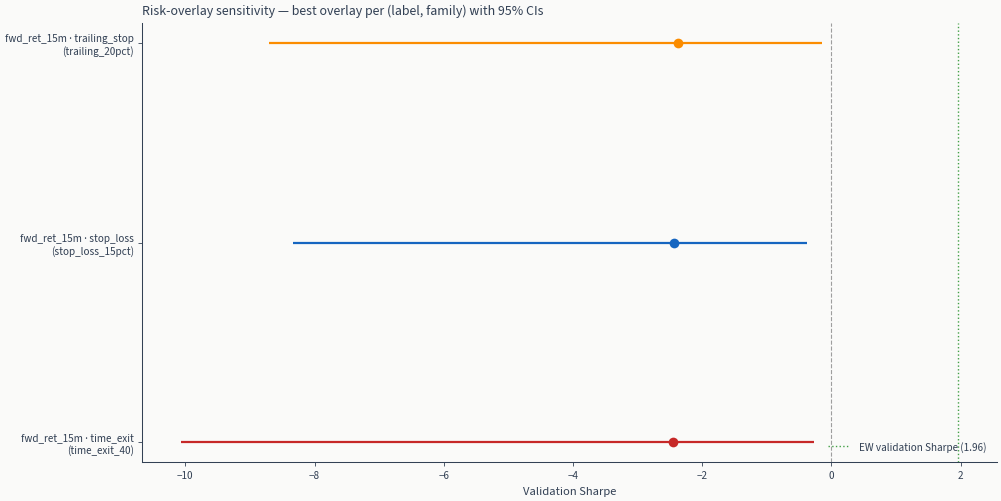

In [27]:
# Forest plot: best overlay per (label, family) with CI bars
families_order = ["trailing_stop", "stop_loss", "time_exit"]
fig, ax = plt.subplots(figsize=(10, 5))
y_pos = []
y_labels = []
y_idx = 0
family_colors = {
    "trailing_stop": "#FB8C00",
    "stop_loss": "#1565C0",
    "time_exit": "#C62828",
}
for lbl in label_order:
    for fam in families_order:
        sub = risk_summary.filter((pl.col("label") == lbl) & (pl.col("risk_family") == fam))
        if sub.is_empty():
            continue
        row = sub.row(0, named=True)
        ax.errorbar(
            row["best_sharpe"],
            y_idx,
            xerr=[
                [row["best_sharpe"] - row["best_ci_lo"]],
                [row["best_ci_hi"] - row["best_sharpe"]],
            ],
            fmt="o",
            color=family_colors.get(fam, "#666"),
            ecolor=family_colors.get(fam, "#666"),
            elinewidth=1.6,
            capsize=4,
            markersize=7,
        )
        y_pos.append(y_idx)
        y_labels.append(f"{lbl} · {fam}\n({row['best_overlay']})")
        y_idx += 1

ax.axvline(0, color="#9E9E9E", linestyle="--", linewidth=0.8)
ax.axvline(
    ew_val["sharpe"],
    color="#43A047",
    linestyle=":",
    linewidth=1.0,
    label=f"EW validation Sharpe ({ew_val['sharpe']:.2f})",
)
ax.set_yticks(y_pos)
ax.set_yticklabels(y_labels, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel("Validation Sharpe")
ax.set_title("Risk-overlay sensitivity — best overlay per (label, family) with 95% CIs")
ax.legend(loc="lower right", fontsize=8, frameon=False)
show_with_alt(
    fig,
    "Horizontal chart of risk-overlay sensitivity. One row per label and family pair on the "
    "vertical axis, running top to bottom, each showing the best overlay's validation Sharpe as "
    "a point with a horizontal bar for its 95 percent confidence interval. A dashed vertical "
    "line marks zero and a further vertical line marks the reference Sharpe. The intervals are "
    "marginal, one per row, so they place each overlay against those two fixed values and not "
    "against each other.",
)

In [28]:
# Compare overlay rescue vs no-overlay baseline per label.
#
# `MAX(sharpe)` over a whole stage is the shape that a constant forecast wins. A prediction
# set holding one value per fold ranks nothing, so the book fills once and never replaces
# anything: it pays almost no cost, and in a cost-dominated sweep that is the cheapest route
# to the top. `num_trades > 0` below was already reaching for this and catches only the
# zero-trade case; the sets that matter here trade once or twice.
#
# It is not the notebook's own rule to restate: `degenerate_prediction_sql` is the same
# clause `resolve_best_backtest_runs` applies, which is why 16 and 17 never had this hole -
# they select through that function and this cell writes its own SQL.
#
# Latent rather than live on the registry this was written against: the per-label maxima are
# real models trading 900 to 3,165 times, and excluding the constants moved no label's
# baseline by any amount. The clause is here so it stays that way when the pool changes,
# because `rescue` below is a difference measured against this number.
no_overlay_baseline = pl.read_database(
    f"""
        SELECT t.label, MAX(bm.sharpe) AS best_signal_sharpe
        FROM backtest_runs b
        JOIN backtest_metrics bm ON bm.backtest_hash  = b.backtest_hash
        JOIN prediction_sets p   ON b.prediction_hash = p.prediction_hash
        JOIN training_runs t     ON p.training_hash   = t.training_hash
        WHERE b.stage = 'signal' AND p.split = 'validation'
          AND bm.sharpe IS NOT NULL AND (bm.num_trades IS NULL OR bm.num_trades > 0)
          {degenerate_prediction_sql("b.prediction_hash")}
        GROUP BY t.label
        """,
    sqlite3.connect(str(_db)),
).filter(pl.col("label").is_in(label_order))

best_overlay_per_label = (
    risk_df.sort("sharpe", descending=True)
    .group_by("label")
    .head(1)
    .select(
        [
            "label",
            "sharpe",
            "sharpe_ci95_lo",
            "sharpe_ci95_hi",
            "risk_name",
            "max_drawdown",
            "num_trades",
        ]
    )
    .rename({"sharpe": "best_overlay_sharpe"})
)
rescue_table = no_overlay_baseline.join(best_overlay_per_label, on="label", how="inner").sort(
    "label"
)
print("Risk-overlay rescue analysis (no-overlay best vs best-overlay):")
print(
    rescue_table.with_columns(rescue=pl.col("best_overlay_sharpe") - pl.col("best_signal_sharpe"))
)

Risk-overlay rescue analysis (no-overlay best vs best-overlay):
shape: (1, 9)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ label     ┆ best_sign ┆ best_over ┆ sharpe_ci ┆ … ┆ risk_name ┆ max_drawd ┆ num_trade ┆ rescue   │
│ ---       ┆ al_sharpe ┆ lay_sharp ┆ 95_lo     ┆   ┆ ---       ┆ own       ┆ s         ┆ ---      │
│ str       ┆ ---       ┆ e         ┆ ---       ┆   ┆ str       ┆ ---       ┆ ---       ┆ f64      │
│           ┆ f64       ┆ ---       ┆ f64       ┆   ┆           ┆ f64       ┆ f64       ┆          │
│           ┆           ┆ f64       ┆           ┆   ┆           ┆           ┆           ┆          │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ fwd_ret_1 ┆ 2.300125  ┆ -2.374849 ┆ -8.698789 ┆ … ┆ trailing_ ┆ -0.771522 ┆ 30619.0   ┆ -4.67497 │
│ 5m        ┆           ┆           ┆           ┆   ┆ 20pct     ┆           ┆           ┆ 4        │
└───────────┴

**How to read the overlay comparison.** Each row pairs a label's best signal-
stage result with its best overlay result, and the difference between them is
what the overlay contributed on that lineage.

The difference is the quantity to read, not the level. Both sides share the
same signal, allocation and costs, so what separates them is the exit rule
alone - which is the only way to attribute a change to the overlay rather than
to the configuration it was applied to.

An overlay changes when positions are closed. It cannot create an edge that
the signal does not have, and its effect on a losing configuration is to change
how that configuration loses. Reading a small improvement as a rescue is the
error this pairing exists to prevent.

## §6 Holdout closure with paired bootstrap

The model deployed on the holdout need not be the one selected on validation.
Retraining the selected model on the holdout's training window can produce
degenerate predictions - near-constant scores that give no ordering to trade -
and when that happens the holdout generator advances to the next trained model
rather than backtesting a model that predicts nothing.

This means the holdout read must be anchored on whichever model was actually
deployed, and compared against *that* model's own validation backtest. Two
paired tests follow: the deployed model against its own validation result,
which asks whether its performance held; and the deployed model against the
equal-weight benchmark over the holdout window, which asks whether it did
better than holding the universe.

Both come from paired comparison on shared days. Subtracting a validation
Sharpe from a holdout Sharpe would discard the pairing and produce a difference
with no usable interval.

The case study has exactly one holdout backtest. Where a conformal-weighted
sibling exists it is a transparency variant and is excluded here by its
allocation method, so the one resolved below is the canonical read.

The holdout is resolved directly rather than by requiring it to share the
selected prediction's lineage, because the deployed model may be a fallback.
The paired tests that follow are then anchored on whichever model was deployed,
against that model's own validation backtest.

In [29]:
# The markdown above states an invariant - exactly one canonical holdout backtest - and
# this asks the registry rather than assuming it. `ORDER BY created_at ASC LIMIT 1` takes
# the OLDEST, so a second holdout registered by a re-run of `19_holdout_backtest` would be
# silently ignored and this section would close the case study on the superseded one. The
# registry is append-only, which is what makes the oldest the wrong tie-break here.
with sqlite3.connect(str(_db)) as _con:
    _ho_rows = _con.execute(
        """
        SELECT b.backtest_hash, p.training_hash, b.created_at
        FROM backtest_runs b
        JOIN prediction_sets p ON b.prediction_hash = p.prediction_hash
        WHERE b.stage IN ('signal','allocation','risk_overlay','holdout')
          AND p.split = 'holdout'
          AND COALESCE(
              json_extract(b.spec_json, '$.strategy.allocation.method'), ''
          ) != 'conformal_weighted'
        ORDER BY b.created_at ASC
        """,
    ).fetchall()
if not _ho_rows:
    msg = (
        f"No canonical holdout backtest registered for {CASE_STUDY}, so §6 has nothing to "
        "close on. `19_holdout_backtest` is what registers it, and it runs after "
        "`18_holdout_predictions` has generated the holdout prediction set."
    )
    raise RuntimeError(msg)
if len(_ho_rows) > 1:
    _listed = ", ".join(f"{h} ({ts})" for h, _, ts in _ho_rows)
    msg = (
        f"{len(_ho_rows)} canonical holdout backtests registered for {CASE_STUDY}: {_listed}. "
        "This section reports one and the registry is append-only, so taking the oldest "
        "would close the case study on a superseded read while the current one sits beside "
        "it. Retire the ones that are not the deployed configuration, or pin the carrier."
    )
    raise RuntimeError(msg)
HO_HASH, _HO_TRAINING, _ = _ho_rows[0]

# Conformal sibling holdout (if registered) — recorded for transparency.
# Keyed off the canonical holdout's own lineage, not the validation selection.
with sqlite3.connect(str(_db)) as _con:
    _ho_conformal_row = _con.execute(
        """
        SELECT b.backtest_hash, bm.sharpe
        FROM backtest_runs b
        JOIN prediction_sets p ON b.prediction_hash = p.prediction_hash
        JOIN backtest_metrics bm ON bm.backtest_hash = b.backtest_hash
        WHERE b.stage IN ('signal','allocation','risk_overlay','holdout')
          AND p.split = 'holdout'
          AND bm.sharpe IS NOT NULL
          AND json_extract(b.spec_json, '$.strategy.allocation.method') = 'conformal_weighted'
          AND p.training_hash = ?
        ORDER BY b.created_at ASC
        LIMIT 1
        """,
        (_HO_TRAINING,),
    ).fetchone()
HO_HASH_CONFORMAL = _ho_conformal_row[0] if _ho_conformal_row else None
HO_SHARPE_CONFORMAL = _ho_conformal_row[1] if _ho_conformal_row else None

print(f"Validation (selected lineage): {TOP_HASH}")
print(f"Holdout (canonical):           {HO_HASH}")
if HO_HASH_CONFORMAL:
    print(
        f"Holdout (conformal sibling):   {HO_HASH_CONFORMAL} "
        f"(Sharpe {HO_SHARPE_CONFORMAL:+.3f}; transparency variant of "
        "canonical baseline, not used for §6 closure)"
    )

ho_full = load_backtest_metrics(CASE_STUDY, backtest_hash=HO_HASH).row(0, named=True)

with sqlite3.connect(str(_db)) as _con:
    _val_self_row = _con.execute(
        "SELECT benchmark_hash FROM backtest_paired_metrics "
        "WHERE challenger_hash = ? AND benchmark_kind = 'val_rank1_self'",
        (HO_HASH,),
    ).fetchone()
if _val_self_row and _val_self_row[0]:
    val_full = load_backtest_metrics(CASE_STUDY, backtest_hash=_val_self_row[0]).row(0, named=True)
else:
    val_full = full

Validation (selected lineage): a2d22880e93f
Holdout (canonical):           7065bf7708c9


In [30]:
# Paired val→ho decay table from load_paired_metrics
val_ho_pair = load_paired_metrics(
    CASE_STUDY,
    challenger_hash=HO_HASH,
    benchmark_kind="val_rank1_self",
)
if val_ho_pair.is_empty():
    print(
        f"[WARN] No val_rank1_self pair registered against holdout {HO_HASH}. "
        "Measured rather than inferred, by calling the producer's own resolution "
        "with this registry: `_val_rank1_carrier` walks the rung-restricted "
        "candidates for one with a matching holdout and finds none, so "
        "`populate_paired_metrics` falls back to the rung leader's prediction "
        "hash as `prefer_prediction_hash`, and `_holdout_lineage_for` pinned on "
        "that hash returns None. Pass the carrier's prediction hash instead and "
        f"the same call resolves {HO_HASH}. What separates them is the label: "
        "the pin is on fwd_ret_15m, where the leader is deep_learning/nlinear at "
        "+2.300, and the carrier that 18 and 19 refit is gbm/default_multiclass "
        "on the fwd_dir_15m variant at +2.416. No fwd_ret_15m candidate has a "
        "holdout, so the walk exhausts. Continuing with NaN val to holdout decay."
    )
    vh = {
        "sharpe_diff": float("nan"),
        "sharpe_diff_ci95_lo": float("nan"),
        "sharpe_diff_ci95_hi": float("nan"),
        "ret_diff": float("nan"),
        "ret_diff_ci95_lo": float("nan"),
        "ret_diff_ci95_hi": float("nan"),
        "max_dd_diff": float("nan"),
        "max_dd_diff_ci95_lo": float("nan"),
        "max_dd_diff_ci95_hi": float("nan"),
        "p_value": float("nan"),
        "prob_challenger_wins": float("nan"),
        "info_ratio": float("nan"),
        "info_ratio_ci95_lo": float("nan"),
        "info_ratio_ci95_hi": float("nan"),
    }
else:
    vh = val_ho_pair.row(0, named=True)


def _diff_row(
    label: str,
    v: float,
    h: float,
    diff: float | None,
    lo: float | None,
    hi: float | None,
    p: float | None,
) -> dict:
    return {
        "metric": label,
        "validation": _fmt(v, ".4f"),
        "holdout": _fmt(h, ".4f"),
        "diff (h−v)": _fmt(diff, ".4f") if diff is not None else "—",
        "diff CI95": f"[{_fmt(lo, '.4f')}, {_fmt(hi, '.4f')}]" if lo is not None else "—",
        "p-value": _fmt(p, ".4f") if p is not None else "—",
    }


val_ho_table = pl.DataFrame(
    [
        _diff_row(
            "Sharpe",
            val_full["sharpe"],
            ho_full["sharpe"],
            vh["sharpe_diff"],
            vh["sharpe_diff_ci95_lo"],
            vh["sharpe_diff_ci95_hi"],
            vh["p_value"],
        ),
        _diff_row(
            "Annualized return",
            val_full["cagr"],
            ho_full["cagr"],
            vh["ret_diff"],
            vh["ret_diff_ci95_lo"],
            vh["ret_diff_ci95_hi"],
            None,
        ),
        _diff_row(
            "Max drawdown",
            val_full["max_drawdown"],
            ho_full["max_drawdown"],
            vh["max_dd_diff"],
            vh["max_dd_diff_ci95_lo"],
            vh["max_dd_diff_ci95_hi"],
            None,
        ),
        _diff_row(
            "Information ratio",
            None,
            None,
            vh["info_ratio"],
            vh["info_ratio_ci95_lo"],
            vh["info_ratio_ci95_hi"],
            None,
        ),
    ]
)
print("val → holdout paired-bootstrap decay (the selected lineage self):")
print(val_ho_table)
print(f"prob_challenger_wins: {vh['prob_challenger_wins']:.3f}")
print(f"CI status (Sharpe diff): {ci_status(vh['sharpe_diff_ci95_lo'], vh['sharpe_diff_ci95_hi'])}")
print()
print(
    "Note: validation and holdout windows are disjoint (validation 2020-07 "
    "→ 2021-06; holdout 2021-07 → 2021-12), so the populator pairs "
    "the bootstrapped Sharpe series by row index after a min-length "
    "truncation. The CI is interpreted as bootstrap-resampled Sharpe "
    "difference under index-paired draws, not as a calendar-aligned overlap."
)

[WARN] No val_rank1_self pair registered against holdout 7065bf7708c9. Measured rather than inferred, by calling the producer's own resolution with this registry: `_val_rank1_carrier` walks the rung-restricted candidates for one with a matching holdout and finds none, so `populate_paired_metrics` falls back to the rung leader's prediction hash as `prefer_prediction_hash`, and `_holdout_lineage_for` pinned on that hash returns None. Pass the carrier's prediction hash instead and the same call resolves 7065bf7708c9. What separates them is the label: the pin is on fwd_ret_15m, where the leader is deep_learning/nlinear at +2.300, and the carrier that 18 and 19 refit is gbm/default_multiclass on the fwd_dir_15m variant at +2.416. No fwd_ret_15m candidate has a holdout, so the walk exhausts. Continuing with NaN val to holdout decay.
val → holdout paired-bootstrap decay (the selected lineage self):
shape: (4, 6)
┌───────────────────┬────────────┬─────────┬────────────┬────────────┬─────────┐


In [31]:
# Paired strategy-vs-EW-benchmark on the holdout window
ho_vs_ew = load_paired_metrics(
    CASE_STUDY,
    challenger_hash=HO_HASH,
    benchmark_kind="equal_weight_holdout_side_artifact",
)
if ho_vs_ew.is_empty():
    print(
        "[WARN] No equal_weight_holdout_side_artifact pair registered against "
        f"holdout {HO_HASH}. Same resolution as the decay pair above, and it "
        "fails at the same step. The holdout itself carries 420 trades and 128 "
        "daily returns, so this is an absent comparison rather than an absent "
        "result. Continuing with NaN diffs."
    )
    he = {
        "sharpe_diff": float("nan"),
        "sharpe_diff_ci95_lo": float("nan"),
        "sharpe_diff_ci95_hi": float("nan"),
        "ret_diff": float("nan"),
        "ret_diff_ci95_lo": float("nan"),
        "ret_diff_ci95_hi": float("nan"),
        "max_dd_diff": float("nan"),
        "max_dd_diff_ci95_lo": float("nan"),
        "max_dd_diff_ci95_hi": float("nan"),
        "p_value": float("nan"),
        "prob_challenger_wins": float("nan"),
        "info_ratio": float("nan"),
        "info_ratio_ci95_lo": float("nan"),
        "info_ratio_ci95_hi": float("nan"),
    }
else:
    he = ho_vs_ew.row(0, named=True)

ew_ho = load_benchmark_metrics(CASE_STUDY, PRIMARY_LABEL, period="holdout")
print("Holdout strategy vs holdout EW universe:")
print(f"  strategy Sharpe:  {ho_full['sharpe']:.3f}")
print(f"  EW Sharpe:        {ew_ho['sharpe']:.3f}")
print(
    "  diff Sharpe: "
    f"{_fmt_ci(he['sharpe_diff'], he['sharpe_diff_ci95_lo'], he['sharpe_diff_ci95_hi'])}"
)
print(f"  p_value:                {he['p_value']:.4f}")
print(f"  prob_challenger_wins:   {he['prob_challenger_wins']:.3f}")
print(
    f"  info_ratio (strategy vs EW): "
    f"{_fmt_ci(he['info_ratio'], he['info_ratio_ci95_lo'], he['info_ratio_ci95_hi'])}"
)
print(f"  CI status: {ci_status(he['sharpe_diff_ci95_lo'], he['sharpe_diff_ci95_hi'])}")

[WARN] No equal_weight_holdout_side_artifact pair registered against holdout 7065bf7708c9. Same resolution as the decay pair above, and it fails at the same step. The holdout itself carries 420 trades and 128 daily returns, so this is an absent comparison rather than an absent result. Continuing with NaN diffs.
Holdout strategy vs holdout EW universe:
  strategy Sharpe:  1.320
  EW Sharpe:        0.924
  diff Sharpe: nan [nan, nan]
  p_value:                nan
  prob_challenger_wins:   nan
  info_ratio (strategy vs EW): nan [nan, nan]
  CI status: no_data


**How to read the two paired rows.** Each reports a difference with an
interval, and the interval is what decides the reading.

The first compares the deployed model's holdout result against its own
validation result. A difference whose interval excludes zero on the negative
side means performance fell by more than the resampling can explain. A
difference whose interval includes zero means this window cannot separate the
two, which on a short holdout is the common outcome and is not evidence that
performance held.

The second compares the strategy against the equal-weight benchmark over the
same holdout days. This is the comparison that matters for whether the strategy
was worth running: a strategy can decay from validation and still beat the
benchmark, or hold its level and still trail it.

The holdout is read once, on the lineage selected in §1, and neither row can be
recomputed against a different configuration without the holdout ceasing to
be one.

## §7 Benchmark-aware diagnostics

Layer 1 reports the universal alpha/beta/IR profile via
`PortfolioAnalysis` against the equal-weight NASDAQ-100 universe.
Layer 2 — equity factor attribution (FF5+MOM with HAC standard errors)
— applies because this is an equity-class case study; for a
dollar-neutral intraday strategy on the NQ100, factor attribution
answers whether residual α remains after standard equity-style risk
decomposition.

In [32]:
metrics = pa.compute_summary_stats()
attr_df = pl.DataFrame(
    [
        {"metric": "alpha (annualized)", "value": _fmt(getattr(metrics, "alpha", None))},
        {"metric": "beta", "value": _fmt(getattr(metrics, "beta", None), ".3f")},
        {"metric": "information ratio", "value": _fmt(getattr(metrics, "information_ratio", None))},
        {"metric": "tracking error", "value": _fmt(getattr(metrics, "tracking_error", None))},
        {"metric": "up capture", "value": _fmt(getattr(metrics, "up_capture", None))},
        {"metric": "down capture", "value": _fmt(getattr(metrics, "down_capture", None))},
    ]
)
print("Layer 1: the selected lineage vs validation EW NASDAQ-100 universe (PortfolioAnalysis):")
print(attr_df)

Layer 1: the selected lineage vs validation EW NASDAQ-100 universe (PortfolioAnalysis):
shape: (6, 2)
┌────────────────────┬────────┐
│ metric             ┆ value  │
│ ---                ┆ ---    │
│ str                ┆ str    │
╞════════════════════╪════════╡
│ alpha (annualized) ┆ 0.1844 │
│ beta               ┆ 0.864  │
│ information ratio  ┆ 1.0033 │
│ tracking error     ┆ —      │
│ up capture         ┆ 0.9427 │
│ down capture       ┆ 1.2076 │
└────────────────────┴────────┘


In [33]:
# Placebo regression: residual α and HAC t-stat from regressing on EW alone.
import statsmodels.api as sm

X = sm.add_constant(bench_arr)
ols = sm.OLS(strat_arr, X).fit(cov_type="HAC", cov_kwds={"maxlags": 5})
alpha_daily = ols.params[0]
alpha_t = ols.tvalues[0]
alpha_p = ols.pvalues[0]
beta_ew = ols.params[1]
beta_t = ols.tvalues[1]
print()
print("Placebo regression (HAC, maxlags=5):")
print(f"  α (daily) = {alpha_daily:.6f}, α (annualized) = {alpha_daily * PERIODS_PER_YEAR:.4f}")
print(f"  α t-stat = {alpha_t:.3f}, p = {alpha_p:.3f}")
print(f"  β        = {beta_ew:.3f}, β t-stat = {beta_t:.3f}")
print(f"  CI status (α): {'excludes_zero_strong' if alpha_p < 0.05 else 'straddles_zero'}")


Placebo regression (HAC, maxlags=5):
  α (daily) = 0.000732, α (annualized) = 0.1844
  α t-stat = 1.482, p = 0.138
  β        = 0.864, β t-stat = 15.602
  CI status (α): straddles_zero


The strategy holds equal value long and short, so its return already nets out
the cost of capital and raw returns are regressed rather than returns in excess
of the risk-free rate. Standard errors are computed to tolerate correlation
between consecutive days.

In [34]:
strategy_rets = pd.Series(
    strat_arr,
    index=pd.to_datetime(aligned["ts"].to_list()),
    name="strategy",
)
factor_start = str(strategy_rets.index.min().date())
factor_end = str(strategy_rets.index.max().date())
factor_data = load_factor_data(start=factor_start, end=factor_end)
reg = run_factor_regression(
    strategy_rets, factor_data, model="ff5_mom", hac_lags=5, dollar_neutral=True
)

print()
print("Layer 2: FF5+MOM regression (HAC, dollar-neutral)")
print(f"  Observations:    {reg['n_obs']}")
print(f"  Strategy Sharpe: {reg['strategy_sharpe']:+.3f}")
print(f"  Residual Sharpe: {reg['residual_sharpe']:+.3f}")
print(f"  R²:              {reg['r_squared']:.3f}")
print(
    f"  Alpha (ann.):    {reg['alpha_annualized']:+.4f} "
    f"(t={reg['alpha_t_stat']:+.2f}, p={reg['alpha_p_value']:.3f})"
)
print()
print("Factor betas (significant at p<0.05 marked *):")
for factor, beta in reg["betas"].items():
    sig = "*" if reg["p_values"][factor] < 0.05 else ""
    print(f"  {factor:8s}: {beta:+.4f}  (t={reg['t_stats'][factor]:+.2f}){sig}")


Layer 2: FF5+MOM regression (HAC, dollar-neutral)
  Observations:    253
  Strategy Sharpe: +2.416
  Residual Sharpe: +1.430
  R²:              0.622
  Alpha (ann.):    +0.1857 (t=+1.50, p=0.134)

Factor betas (significant at p<0.05 marked *):
  Mkt-RF  : +0.9558  (t=+15.55)*
  SMB     : -0.1290  (t=-1.54)
  HML     : -0.2480  (t=-2.71)*
  RMW     : -0.0875  (t=-0.61)
  CMA     : +0.2940  (t=+2.29)*
  MOM     : +0.0038  (t=+0.08)


In [35]:
# Block bootstrap CIs for alpha and factor betas
boot = compute_bootstrap_ci(
    strategy_rets,
    factor_data,
    model="ff5_mom",
    n_boot=1000,
    block_size=20,
    dollar_neutral=True,
    seed=42,
)
if boot.get("n_boot", 0) > 0:
    print(f"Bootstrap CIs (n={boot['n_boot']}, block=20 days):")
    print(f"  Alpha (ann.): [{boot['alpha_ann_lo']:+.4f}, {boot['alpha_ann_hi']:+.4f}]")
    for factor in reg["factor_columns"]:
        lo_key, hi_key = f"{factor}_lo", f"{factor}_hi"
        if lo_key in boot:
            print(f"  {factor:8s}: [{boot[lo_key]:+.4f}, {boot[hi_key]:+.4f}]")

Bootstrap CIs (n=1000, block=20 days):
  Alpha (ann.): [+0.0207, +0.4818]
  Mkt-RF  : [+0.9037, +1.0992]
  SMB     : [-0.3400, -0.0366]
  HML     : [-0.4079, -0.0556]
  RMW     : [-0.4091, +0.1285]
  CMA     : [-0.0412, +0.6251]
  MOM     : [-0.0916, +0.0933]


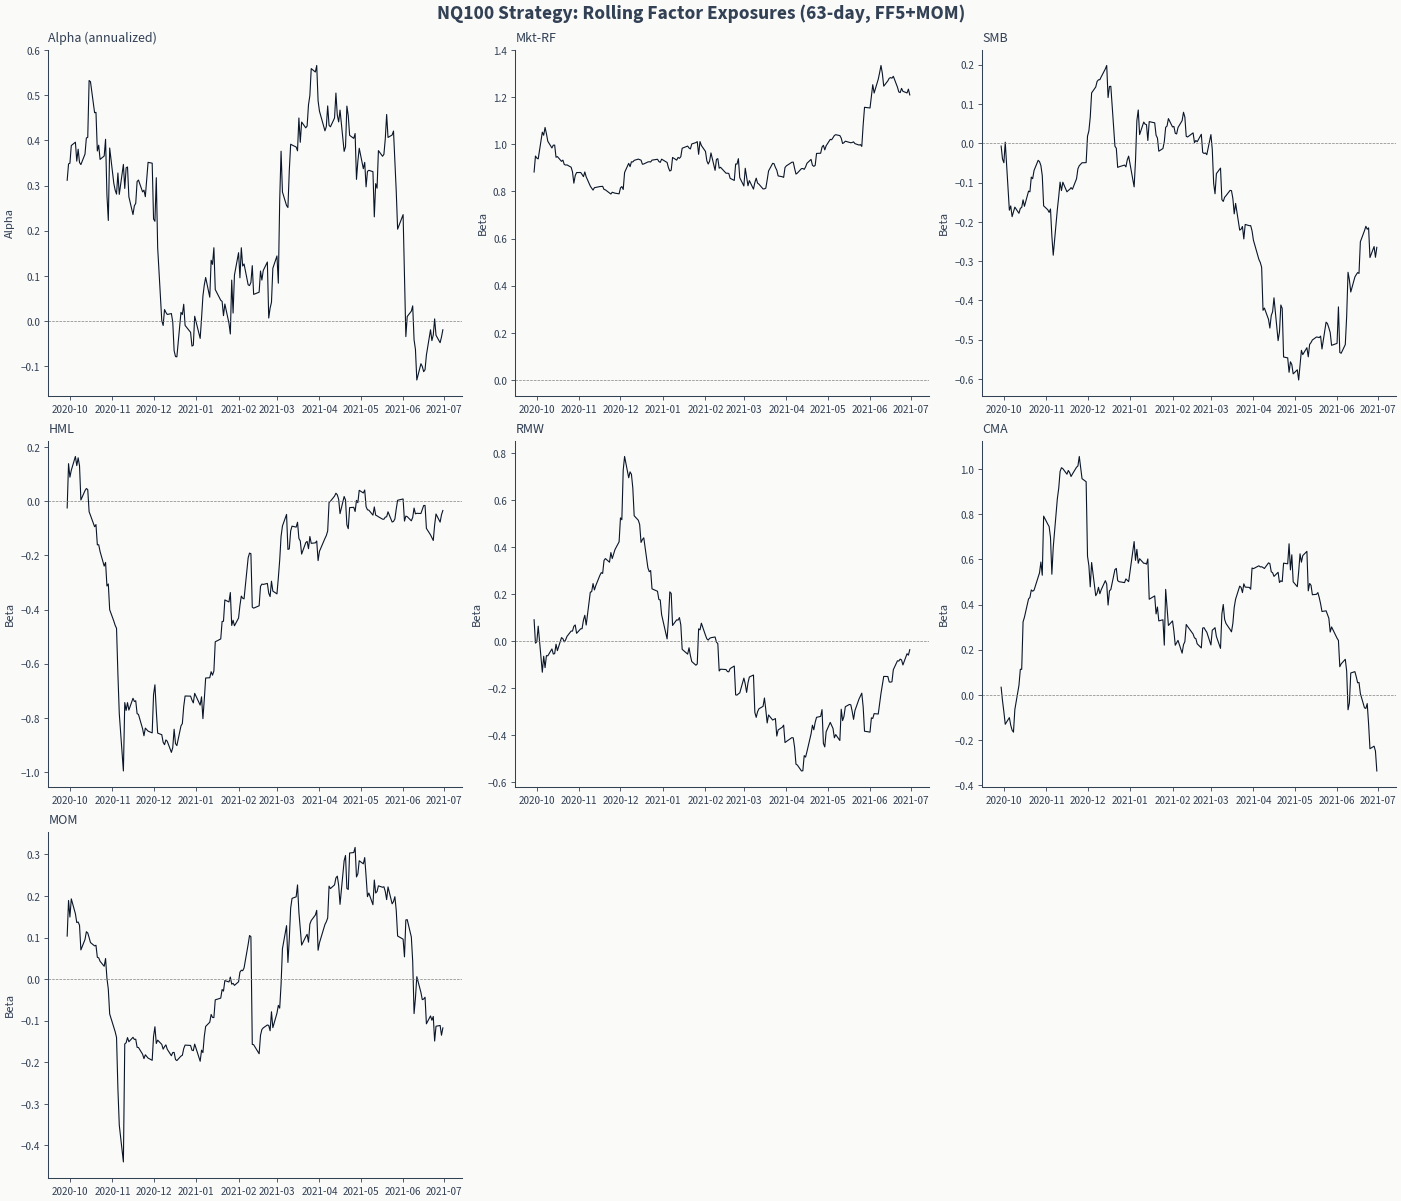

In [36]:
# Rolling factor exposures (63-day window ≈ 3 months)
rolling = compute_rolling_exposures(
    strategy_rets, factor_data, model="ff5_mom", window=63, dollar_neutral=True
)
fig_roll = plot_rolling_exposures(
    rolling, title="NQ100 Strategy: Rolling Factor Exposures (63-day, FF5+MOM)"
)
show_with_alt(
    fig_roll,
    "Grid of line panels, one per series: annualized alpha first, then one "
    "coefficient panel for each factor in the FF5+MOM model. Each panel plots the "
    "63-day rolling value against date with a dashed line at zero; the y-axis is "
    "Alpha on the first panel and Beta on the rest. Unused grid slots are hidden.",
)

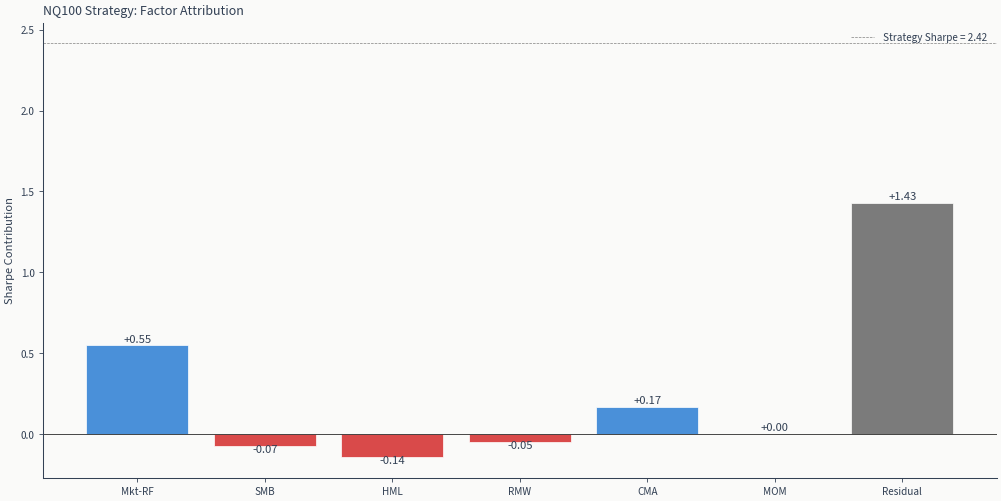

In [37]:
# Attribution waterfall
fig_attr = plot_attribution_waterfall(reg, title="NQ100 Strategy: Factor Attribution")
show_with_alt(
    fig_attr,
    "Bar chart with one bar per factor and a grey Residual bar at the right. The "
    "y-axis is Sharpe Contribution, bars are blue above zero and red below, each "
    "carries its value as a label, and a dashed horizontal line marks the strategy's "
    "own Sharpe with its value in the legend.",
)

attr_summary = format_attribution_summary(reg, boot)

**How to read the factor attribution.** The regression asks how much of the
strategy's return is explained by exposure to known equity factors, and what
is left over once they are accounted for.

The loadings say whether the long-minus-short construction picked up a factor
tilt it did not intend. A strategy meant to be neutral that carries a large
loading is taking a bet it did not mean to take, and its result is partly that
factor's result.

The intercept is what the factors do not explain. Read it with its interval:
the block bootstrap interval is wider than the parametric one because it does
not assume the errors are independent across days, and it is the one to rely
on. An intercept whose interval spans zero means the factor model has absorbed
whatever the strategy produced, leaving nothing attributable to the strategy
itself.

The placebo regression against the benchmark alone is the control. Comparing
the two says how much of the reading depends on the wider factor set rather
than on market exposure.

**Read every exposure off the regression printout above, including its sign and
its rank.** `plot_attribution_waterfall` gives each factor
`beta / sum(|beta|) * (strategy_sharpe - residual_sharpe)`, so two things are
true of the bars that are not true of the betas. The split is proportional to
the absolute loading rather than to beta times that factor's own Sharpe, so a
large loading on a factor that returned nothing over the window still draws a
tall bar. And when the factor-explained term is negative - which it is whenever
the residual Sharpe exceeds the strategy's - the multiplication flips every
bar, so the signs and the ordering on the chart are the reverse of the
loadings. The figure shows the shape of the decomposition; no number should be
quoted from it.

## §8 Strategy tear sheet

The diagnostic library renders the selected lineage's full tear sheet
directly from the on-disk artifacts; the validation-window
equal-weight NASDAQ-100 benchmark is wired in as the comparison
series. The tear sheet HTML is written under `OUTPUT_DIR` and is
gitignored — readers regenerate it locally.

In [38]:
backtest_dir = CASE_DIR / "run_log" / "backtest" / TOP_HASH
ho_dir = CASE_DIR / "run_log" / "backtest" / HO_HASH
ho_has_trades = (ho_dir / "trades.parquet").exists()
print(f"Validation backtest_dir: {backtest_dir} (trades.parquet present)")
print(f"Holdout backtest_dir:    {ho_dir} (trades.parquet present: {ho_has_trades})")
print(
    "Tear sheet sourced from validation backtest; the strategy-analysis convention "
    "renders tear sheets from the validation lineage."
)

# generate_tearsheet_from_run_artifacts expects a 1-D series of benchmark
# returns, not a DataFrame; pass the daily-aggregated EW series.
bench_series = aligned["benchmark"].to_numpy()

meta = BacktestReportMetadata(
    title="NASDAQ-100 Microstructure — Rank-1 Lineage",
    strategy_name=f"{RANK1_FAMILY}/{RANK1_CONFIG} — {PRIMARY_LABEL}",
    universe=(
        f"{setup['universe']['n_assets']} declared NASDAQ-100 constituents, "
        f"{(setup['decision'].get('cadence_by_label') or {}).get(RANK1_LABEL, setup['decision']['bar_frequency'])} cadence"
    ),
    benchmark_name="NQ100 equal-weight universe (validation window)",
    evaluation_window=f"{aligned['ts'].min()} to {aligned['ts'].max()}",
    calendar=setup["evaluation"]["calendar"],
)

tear_path = OUTPUT_DIR / f"{CASE_STUDY}_tearsheet.html"
html = generate_tearsheet_from_run_artifacts(
    backtest_dir,
    template="risk_manager",
    benchmark=bench_series,
    benchmark_name="EW NQ100 universe (validation)",
    calendar=setup["evaluation"]["calendar"],
    report_metadata=meta,
    output_path=str(tear_path),
)
print(f"Tear sheet written to: {tear_path}")
print(f"HTML size: {len(html):,} bytes")

Validation backtest_dir: case_studies/nasdaq100_microstructure/run_log/backtest/a2d22880e93f (trades.parquet present)
Holdout backtest_dir:    case_studies/nasdaq100_microstructure/run_log/backtest/7065bf7708c9 (trades.parquet present: True)
Tear sheet sourced from validation backtest; the strategy-analysis convention renders tear sheets from the validation lineage.


/home/stefan/ml4t/public-nasdaq/.venv/lib/python3.14/site-packages/ml4t/diagnostic/integration/backtest_profile.py:302: UserWarning: Prediction enrichment failed: datatypes of join keys don't match - `entry_time`: datetime[μs] on left does not match `timestamp`: datetime[μs, UTC] on right (and no other type was available to cast to). ML trade-alignment charts will be unavailable.
  prediction_trades_df = self.prediction_enriched_trades_df


Tear sheet written to: case_studies/ch20_nasdaq100_microstructure/nasdaq100_microstructure_tearsheet.html
HTML size: 8,879,598 bytes


## §9 Pre-Ch20 judgment & handoff

This section is the explicit hand-off point to Chapter 20. Numbers
below stay strictly inside nasdaq100_microstructure — cross-case-study
comparison is Ch20's lane.

In [39]:
op_profile = compute_operating_profile(lineage, setup)
# `compute_operating_profile` reads `evaluation_protocol.rebalance_frequency`, which this
# setup does not declare, so the cadence is supplied here.
#
# Per label, not `decision.bar_frequency`. That key is the case-study default and the
# carrier need not be on the primary label - today it is not - while the cadence the run
# actually decided on is `decision.cadence_by_label[label]`, which is what
# `resolve_decision_schedule` was handed. The two agree on every 15-minute label and
# disagree on `fwd_ret_60m`, so reading the default would report a cadence four times
# faster than the strategy traded.
CARRIER_CADENCE = (setup["decision"].get("cadence_by_label") or {}).get(
    RANK1_LABEL, setup["decision"]["bar_frequency"]
)
op_profile = op_profile.with_columns(
    pl.when(pl.col("property") == "Trading cadence")
    .then(pl.lit(CARRIER_CADENCE))
    .otherwise(pl.col("value"))
    .alias("value")
)
print("Operating profile (nasdaq100_microstructure, validation window):")
print(op_profile)
print()
print(
    f"Sharpe: {_fmt_ci(val_full['sharpe'], val_full['sharpe_ci95_lo'], val_full['sharpe_ci95_hi'])}"
)
print(f"Info ratio (vs EW val): {_fmt_ci(getattr(metrics, 'information_ratio', None), None, None)}")
print(f"Max drawdown: {val_full['max_drawdown']:.3f}")

Operating profile (nasdaq100_microstructure, validation window):
shape: (5, 2)
┌─────────────────────────────────┬───────────┐
│ property                        ┆ value     │
│ ---                             ┆ ---       │
│ str                             ┆ str       │
╞═════════════════════════════════╪═══════════╡
│ Trading cadence                 ┆ 15_minute │
│ Portfolio concentration (top_k… ┆ -         │
│ Allocator                       ┆ -         │
│ Cost assumption                 ┆ -         │
│ Worst drawdown                  ┆ -95.3%    │
└─────────────────────────────────┴───────────┘

Sharpe: 2.416 [1.011, 4.123]
Info ratio (vs EW val): 1.003 [—, —]
Max drawdown: -0.082


In [40]:
# Kill-condition assessment (universal gates — see §1)
gate1_status = gate1_validation_sharpe_geq_zero(val_full["sharpe_ci95_lo"])
_gate1_phrase = {
    "pass": "≥ 0 (passes)",
    "fail": "< 0 (fails)",
    "no_data": "CI unavailable",
}[gate1_status]
gate1_evidence = (
    f"Sharpe CI lower bound = {_fmt(val_full['sharpe_ci95_lo'], '.3f')} ({_gate1_phrase})"
)
gate2_ci_status = ci_status(he["sharpe_diff_ci95_lo"], he["sharpe_diff_ci95_hi"])
gate2_status = gate2_holdout_diff_not_excludes_zero_negatively(gate2_ci_status, he["sharpe_diff"])
gate2_evidence = (
    f"Holdout strategy vs EW diff-Sharpe = "
    f"{_fmt_ci(he['sharpe_diff'], he['sharpe_diff_ci95_lo'], he['sharpe_diff_ci95_hi'])} "
    f"({gate2_ci_status})"
)

print("Kill-condition gates:")
print(f"  [{fmt_gate(gate1_status)}] Validation Sharpe CI lower bound ≥ 0:")
print(f"      {gate1_evidence}")
print(f"  [{fmt_gate(gate2_status)}] Holdout strategy CI does not exclude zero negatively:")
print(f"      {gate2_evidence}")

Kill-condition gates:
  [PASS] Validation Sharpe CI lower bound ≥ 0:
      Sharpe CI lower bound = 1.011 (≥ 0 (passes))
  [NO DATA] Holdout strategy CI does not exclude zero negatively:
      Holdout strategy vs EW diff-Sharpe = nan [nan, nan] (no_data)


### What the two gates establish, and what they cannot

The gates above are stated so that failing them is possible. Each asks a
question with a definite answer on this evidence, and each is answered from an
interval rather than from a point estimate.

The first asks whether the validation result is distinguishable from zero on
its favourable side. A strategy whose interval includes zero has not shown that
it makes money on the window it was developed on, which is the weakest
possible bar and the one to apply first.

The second asks whether the holdout result is distinguishable from the
benchmark on the unfavourable side. It is deliberately not the mirror of the
first. Passing does not establish that the strategy works, only that this
window does not establish that it fails; a holdout of a few months is short
enough that failing to reject is a weak statement.

Both are read on the strategy selected in §1, evaluated on the holdout exactly
once. Neither can be re-run against a different configuration without the
holdout ceasing to be one.

The cost and overlay sweeps in §5 vary one field at a time against that same
lineage, so the differences they show are attributable to the field varied.
What they cannot establish is a level: a sweep in which every cell falls on the
same side of zero says the conclusion does not depend on where in the swept
range the truth lies, which is a stronger statement about robustness than
about profitability.

**What this analysis does not cover.** The holdout window is short relative to
the block length the bootstrap resamples, so the interval widths reflect that
structure as well as the strategy's variability. No sector or position limit is
applied, and this universe is concentrated in one sector, so a production
version would constrain that exposure. The cost model used for the registered
results combines a fixed per-share commission with a measured per-asset
half-spread; the sweeps use a simplified single-axis cost so cadence and cost
can be read together.

### The gates on this run

In [41]:
print(f"Selected lineage: {RANK1_FAMILY}/{RANK1_CONFIG} on {RANK1_LABEL}")
print(f"  backtest {TOP_HASH}  prediction {TOP_PHASH}")
print(f"[{fmt_gate(gate1_status)}] Validation Sharpe interval lower bound at or above zero")
print(f"    {gate1_evidence}")
print(f"[{fmt_gate(gate2_status)}] Holdout difference from benchmark not negative-excluding")
print(f"    {gate2_evidence}")

Selected lineage: gbm/default_multiclass on fwd_dir_15m
  backtest a2d22880e93f  prediction 4893bf8b35dc
[PASS] Validation Sharpe interval lower bound at or above zero
    Sharpe CI lower bound = 1.011 (≥ 0 (passes))
[NO DATA] Holdout difference from benchmark not negative-excluding
    Holdout strategy vs EW diff-Sharpe = nan [nan, nan] (no_data)


In [42]:
# Strategy-assessment JSON: extend the existing schema with strategy-analysis notebook fields.
search_ctx = ctx
assessment = {
    "case_study": CASE_STUDY,
    "primary_label": PRIMARY_LABEL,
    "spine_version": "v1",
    "rank1": {
        "family": RANK1_FAMILY,
        "config_name": RANK1_CONFIG,
        "label": RANK1_LABEL,
        "prediction_hash": TOP_PHASH,
        "validation_backtest_hash": TOP_HASH,
        "validation_backtest_hash_cohort_leader": _cohort_leader_hash,
        "holdout_backtest_hash": HO_HASH,
        "holdout_backtest_hash_conformal_sibling": HO_HASH_CONFORMAL,
        "holdout_sharpe_conformal_sibling": (
            float(HO_SHARPE_CONFORMAL) if HO_SHARPE_CONFORMAL is not None else None
        ),
    },
    "cohort_leader_sibling": (
        {
            "cohort_stage": _cohort_stage,
            "cohort_leader_hash": _cohort_leader_hash,
            "cohort_leader_sharpe": (
                float(_cohort_leader_sharpe) if _cohort_leader_sharpe is not None else None
            ),
            "spine_rank1_sharpe": val_full["sharpe"],
            "divergence_reason": (
                "cross_stage_alignment_library_limit: selected stage cohort row absent; "
                f"cascade resolved to family/{_cohort_stage}/{RANK1_LABEL}/{RANK1_FAMILY}"
                if (_cohort_stage and _cohort_stage != _stage_for_rank1)
                else "rank1_is_cohort_stage_match"
            ),
        }
        if _cohort_leader_hash is not None
        else None
    ),
    "headline_performance": {
        "sharpe": {
            "point": val_full["sharpe"],
            "ci95_lo": val_full["sharpe_ci95_lo"],
            "ci95_hi": val_full["sharpe_ci95_hi"],
            "ci_status": sharpe_status,
        },
        "sortino": {
            "point": val_full["sortino"],
            "ci95_lo": val_full["sortino_ci95_lo"],
            "ci95_hi": val_full["sortino_ci95_hi"],
        },
        "ann_return": {
            "point": val_full["cagr"],
            "ci95_lo": val_full["ann_return_ci95_lo"],
            "ci95_hi": val_full["ann_return_ci95_hi"],
        },
        "max_drawdown": {
            "point": val_full["max_drawdown"],
            "ci95_lo": val_full["max_dd_ci95_lo"],
            "ci95_hi": val_full["max_dd_ci95_hi"],
        },
        "psr_pvalue": val_full["psr_pvalue"],
        "bootstrap_block_length": int(val_full["bootstrap_block_length"]),
        "bootstrap_n": int(val_full["bootstrap_n"]),
    },
    "selection_bias": {
        "architecture": "cohort_metrics",
        "cohort_cascade_stage": _cohort_stage,
        "cohort_cascade_fallback_used": (
            _cohort_stage != _stage_for_rank1 if _cohort_stage else None
        ),
        "cohort_leader_hash": _cohort_leader_hash,
        "cohort_leader_sharpe": (
            float(_cohort_leader_sharpe) if _cohort_leader_sharpe is not None else None
        ),
        "k_variants": int(val_full["k_variants"]) if val_full["k_variants"] is not None else None,
        "n_trials_effective_mp": (
            float(val_full.get("n_trials_effective_mp"))
            if val_full.get("n_trials_effective_mp") is not None
            else None
        ),
        "n_trials_effective_er": (
            float(val_full.get("n_trials_effective_er"))
            if val_full.get("n_trials_effective_er") is not None
            else None
        ),
        "dsr_er": val_full.get("dsr_er"),
        "dsr_er_pvalue": val_full.get("dsr_er_pvalue"),
        "dsr_mp": val_full.get("dsr_mp"),
        "dsr_mp_pvalue": val_full.get("dsr_mp_pvalue"),
        "dsr_raw": val_full.get("dsr_raw"),
        "dsr_raw_pvalue": val_full.get("dsr_raw_pvalue"),
        "expected_max_sharpe_er": val_full.get("expected_max_sharpe_er"),
        "expected_max_sharpe_mp": val_full.get("expected_max_sharpe_mp"),
        "expected_max_sharpe_raw": val_full.get("expected_max_sharpe_raw"),
        "min_trl_periods_er": (
            None
            if val_full.get("min_trl_periods_er") in (None, float("inf"))
            else val_full.get("min_trl_periods_er")
        ),
        "pbo": val_full.get("pbo"),
        "pbo_n_combinations": val_full.get("pbo_n_combinations"),
        "pbo_n_folds": val_full.get("pbo_n_folds"),
    },
    "benchmark_relative": {
        "benchmark_name": "equal_weight_universe",
        "benchmark_validation_sharpe": ew_val["sharpe"],
        "benchmark_holdout_sharpe": ew_ho["sharpe"],
        "alpha_annualized_placebo": float(alpha_daily * PERIODS_PER_YEAR),
        "alpha_t_hac": float(alpha_t),
        "beta_to_ew": float(beta_ew),
        "factor_attribution": {
            "status": "applicable",
            "model": "ff5_mom_hac",
            "n_obs": int(reg["n_obs"]),
            "alpha_annualized": float(reg["alpha_annualized"]),
            "alpha_t_hac": float(reg["alpha_t_stat"]),
            "alpha_p_value": float(reg["alpha_p_value"]),
            "residual_sharpe": float(reg["residual_sharpe"]),
            "r_squared": float(reg["r_squared"]),
            "betas": {f: float(b) for f, b in reg["betas"].items()},
            "classification": attr_summary.get("classification"),
        },
    },
    "holdout_decay": {
        "val_hash": TOP_HASH,
        "holdout_hash": HO_HASH,
        "sharpe_diff": vh["sharpe_diff"],
        "sharpe_diff_ci95_lo": vh["sharpe_diff_ci95_lo"],
        "sharpe_diff_ci95_hi": vh["sharpe_diff_ci95_hi"],
        "sharpe_diff_p_value": vh["p_value"],
        "info_ratio": vh["info_ratio"],
        "decay_classification": ci_status(vh["sharpe_diff_ci95_lo"], vh["sharpe_diff_ci95_hi"]),
        "vs_ew_holdout": {
            "sharpe_diff": he["sharpe_diff"],
            "sharpe_diff_ci95_lo": he["sharpe_diff_ci95_lo"],
            "sharpe_diff_ci95_hi": he["sharpe_diff_ci95_hi"],
            "p_value": he["p_value"],
            "ci_status": ci_status(he["sharpe_diff_ci95_lo"], he["sharpe_diff_ci95_hi"]),
        },
    },
    "search_context": {
        "total_signal_backtests": int(search_ctx["total"]),
        "median_sharpe": search_ctx["median_sharpe"],
        "p90_sharpe": search_ctx["p90_sharpe"],
        "pct_positive": search_ctx["pct_positive"],
    },
    "cost_sensitivity": {
        "grid_shape": {
            "labels": label_order,
            "n_cost_levels": int(cost_curve_per_label["cost_bps"].n_unique()),
            "configs_per_cell": 3,
            "total_rows": int(cost_df.height),
        },
        "per_label": [
            {
                "label": lbl,
                "best_config_at_zero_cost": {
                    "family": cost_curve_per_label.filter(
                        (pl.col("label") == lbl) & (pl.col("cost_bps") == 0)
                    ).row(0, named=True)["best_family"],
                    "config_name": cost_curve_per_label.filter(
                        (pl.col("label") == lbl) & (pl.col("cost_bps") == 0)
                    ).row(0, named=True)["best_config"],
                    "sharpe": float(
                        cost_curve_per_label.filter(
                            (pl.col("label") == lbl) & (pl.col("cost_bps") == 0)
                        ).row(0, named=True)["sharpe_max"]
                    ),
                    "ci_lo": float(
                        cost_curve_per_label.filter(
                            (pl.col("label") == lbl) & (pl.col("cost_bps") == 0)
                        ).row(0, named=True)["best_ci_lo"]
                    ),
                    "ci_hi": float(
                        cost_curve_per_label.filter(
                            (pl.col("label") == lbl) & (pl.col("cost_bps") == 0)
                        ).row(0, named=True)["best_ci_hi"]
                    ),
                    "num_trades": float(
                        cost_curve_per_label.filter(
                            (pl.col("label") == lbl) & (pl.col("cost_bps") == 0)
                        ).row(0, named=True)["best_n_trades"]
                    ),
                    "avg_turnover": float(
                        cost_curve_per_label.filter(
                            (pl.col("label") == lbl) & (pl.col("cost_bps") == 0)
                        ).row(0, named=True)["best_avg_turnover"]
                    ),
                },
                "breakeven": {
                    "point_estimate_max_bps": (
                        None
                        if cost_curve_per_label.filter(
                            (pl.col("label") == lbl) & (pl.col("sharpe_max") > 0)
                        ).is_empty()
                        else float(
                            cost_curve_per_label.filter(
                                (pl.col("label") == lbl) & (pl.col("sharpe_max") > 0)
                            )["cost_bps"].max()
                        )
                    ),
                    "ci_aware_max_bps": (
                        None
                        if cost_curve_per_label.filter(
                            (pl.col("label") == lbl) & (pl.col("best_ci_lo") > 0)
                        ).is_empty()
                        else float(
                            cost_curve_per_label.filter(
                                (pl.col("label") == lbl) & (pl.col("best_ci_lo") > 0)
                            )["cost_bps"].max()
                        )
                    ),
                },
            }
            for lbl in label_order
            if not cost_curve_per_label.filter(
                (pl.col("label") == lbl) & (pl.col("cost_bps") == 0)
            ).is_empty()
        ],
        "realistic_friction_setup_yaml": dict(setup["costs"]),
    },
    "risk_overlay_sensitivity": {
        "grid_shape": {
            "labels": label_order,
            "n_overlays_per_label": 81,
            "total_rows": int(risk_df.height),
        },
        "best_per_label": [
            {
                "label": row["label"],
                "no_overlay_baseline_sharpe": float(row["best_signal_sharpe"]),
                "best_overlay_name": row["risk_name"],
                "best_overlay_sharpe": float(row["best_overlay_sharpe"]),
                "ci_lo": float(row["sharpe_ci95_lo"]),
                "ci_hi": float(row["sharpe_ci95_hi"]),
                "ci_status": ci_status(row["sharpe_ci95_lo"], row["sharpe_ci95_hi"]),
                "max_drawdown": float(row["max_drawdown"]),
                "num_trades": float(row["num_trades"]),
                "rescue_sharpe_units": float(
                    row["best_overlay_sharpe"] - row["best_signal_sharpe"]
                ),
            }
            for row in rescue_table.to_dicts()
        ],
        "best_overlay_family_per_label": [
            {
                "label": row["label"],
                "risk_family": row["risk_family"],
                "best_overlay": row["best_overlay"],
                "best_sharpe": float(row["best_sharpe"]),
                "ci_lo": float(row["best_ci_lo"]),
                "ci_hi": float(row["best_ci_hi"]),
            }
            for row in risk_summary.to_dicts()
        ],
    },
    "kill_gates": {
        "validation_sharpe_ci_lower_bound_geq_zero": gate_passes(gate1_status),
        "holdout_vs_ew_ci_does_not_exclude_zero_negatively": gate_passes(gate2_status),
    },
    "ch20_handoff": {
        "contributes_to": [
            "Ch20 nb01 — cross-CS the selected lineage Sharpe and holdout-decay aggregation",
            "Ch20 nb04 — cost-survival comparison (cadence × cost grid + overlay rescue)",
            "Ch20 nb05 — regime risk layer (position-level overlays modulate magnitude; do not reverse loss)",
        ],
        "asset_class_label": "long_short_equity_intraday",
        "rebalance_step_bars": setup["labels"]["rebalance_step"][PRIMARY_LABEL],
    },
}
assessment_path = write_strategy_assessment(CASE_STUDY, assessment)
print(f"strategy_assessment.json written to: {assessment_path}")

strategy_assessment.json written to: case_studies/nasdaq100_microstructure/results/strategy_assessment.json
